In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import gamma as scipy_gamma
import os
import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"

plt.close("all")

# ============================================================
# AUTOMATIC SVG SAVING FOR EVERY MATPLOTLIB FIGURE
# Every figure displayed with plt.show() is saved automatically.
# Figures already saved explicitly as SVG are not duplicated.
# ============================================================

from pathlib import Path
import re
import matplotlib.pyplot as plt
from matplotlib.figure import Figure

SAVE_FIGURES = True
SAVE_DIR = r"/Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp"
FIGURE_OUTPUT_DIR = SAVE_DIR
AUTO_FIGURE_PREFIX = "sinusoidal_upramp"
AUTO_SVG_DPI = 300

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

def _safe_figure_name(text):
    """Convert a plot title into a filename-safe label."""
    text = str(text).strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^A-Za-z0-9_.-]+", "", text)
    return text[:80].strip("._-") or "figure"

def _figure_title_for_filename(fig):
    """Use a suptitle or the first non-empty axis title when available."""
    if getattr(fig, "_suptitle", None) is not None:
        text = fig._suptitle.get_text()
        if str(text).strip():
            return _safe_figure_name(text)
    for ax in fig.axes:
        text = ax.get_title()
        if str(text).strip():
            return _safe_figure_name(text)
    return "figure"

# Track explicit SVG saves so the automatic saver does not create duplicates.
if not hasattr(Figure, "_all_svg_original_savefig"):
    Figure._all_svg_original_savefig = Figure.savefig

    def _tracked_savefig(self, fname, *args, **kwargs):
        result = Figure._all_svg_original_savefig(self, fname, *args, **kwargs)
        requested_format = str(kwargs.get("format", "")).lower()
        filename = str(fname).lower()
        if requested_format == "svg" or filename.endswith(".svg"):
            self._already_saved_as_svg = True
        return result

    Figure.savefig = _tracked_savefig

# Continue numbering after any existing automatic SVG files.
_existing_auto_files = list(Path(SAVE_DIR).glob(f"{AUTO_FIGURE_PREFIX}_auto_*.svg"))
_existing_numbers = []
for _path in _existing_auto_files:
    _match = re.search(r"_auto_(\d+)_", _path.name)
    if _match:
        _existing_numbers.append(int(_match.group(1)))
AUTO_FIGURE_COUNTER = max(_existing_numbers, default=0)

# Preserve the genuine Matplotlib show function only once.
if not hasattr(plt, "_all_svg_original_show"):
    plt._all_svg_original_show = plt.show

def _save_all_open_figures_as_svg():
    """Save every currently open, not-yet-saved Matplotlib figure."""
    global AUTO_FIGURE_COUNTER

    if not SAVE_FIGURES:
        return

    output_dir = Path(SAVE_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)

    for figure_number in plt.get_fignums():
        fig = plt.figure(figure_number)

        if getattr(fig, "_already_saved_as_svg", False):
            continue

        AUTO_FIGURE_COUNTER += 1
        title_label = _figure_title_for_filename(fig)
        filename = (
            f"{AUTO_FIGURE_PREFIX}_auto_"
            f"{AUTO_FIGURE_COUNTER:03d}_{title_label}.svg"
        )
        save_path = output_dir / filename

        fig.savefig(
            save_path,
            format="svg",
            bbox_inches="tight",
            dpi=AUTO_SVG_DPI,
        )
        fig._already_saved_as_svg = True
        print(f"Saved SVG: {save_path}")

def _show_and_save_svg(*args, **kwargs):
    _save_all_open_figures_as_svg()
    return plt._all_svg_original_show(*args, **kwargs)

plt.show = _show_and_save_svg

print(f"Automatic SVG saving is ON: {SAVE_DIR}")
# ============================================================

# ---------- simple linear gain+offset fit ----------
def fit_gain_offset(model, data):
    """
    Find a, b such that data ≈ a*model + b (least squares).
    NaN-safe.
    """
    model = np.asarray(model, dtype=float)
    data  = np.asarray(data,  dtype=float)
    m = np.isfinite(model) & np.isfinite(data)
    if m.sum() < 3:
        return np.nan, np.nan
    A = np.vstack([model[m], np.ones_like(model[m])]).T
    a, b = np.linalg.lstsq(A, data[m], rcond=None)[0]
    return a, b

def r2_nan(y_true, y_pred):
    """
    NaN-safe R^2.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 3:
        return np.nan
    yt = y_true[m]
    yp = y_pred[m]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    if ss_tot <= 0:
        return np.nan
    return 1.0 - ss_res / ss_tot

# ---- helper: snap limits to nearest 0.5 ----
def round_down_to_half(x):
    return 0.5 * np.floor(x / 0.5)

def round_up_to_half(x):
    return 0.5 * np.ceil(x / 0.5)

def compute_ylim_from_traces(traces):
    """
    traces: list of 1D arrays (data + model fits)
    Returns (ymin, ymax) snapped to 0.5 grid,
    strictly enclosing the data.
    """
    vals = []
    for t in traces:
        t = np.asarray(t, dtype=float)
        t = t[np.isfinite(t)]
        if t.size > 0:
            vals.append(t)

    if len(vals) == 0:
        return (-0.5, 0.5)

    vmin = min(np.min(v) for v in vals)
    vmax = max(np.max(v) for v in vals)

    lo = round_down_to_half(vmin)
    hi = round_up_to_half(vmax)

    # safety (rare edge case)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = (-0.5, 0.5)

    return (lo, hi)


Automatic SVG saving is ON: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp


In [25]:
import hashlib
import random
import numpy as np  # make sure np is in scope here

def stable_seed(*parts, base=1, mod=2**31 - 1):
    """
    Deterministic integer seed from arbitrary strings/ints.
    Stable across runs, machines, and column order.
    """
    s = "|".join(str(p) for p in parts)
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return (base + int(h[:8], 16)) % mod

def set_all_seeds(seed: int):
    """
    Seed all RNGs you directly use.
    """
    seed = int(seed)
    np.random.seed(seed)
    random.seed(seed)


Savitzky–Golay temp smoothing: window = 31 samples (~3.10 s), polyorder = 2
Loaded: Sinusoidal upramp Tc25
File: /Users/sk3526/Library/CloudStorage/OneDrive-YaleUniversity/github_repos/Diaz-Garcia-and-Beagan-et-al.-2026-AFD-/AFD_modeling_Fig_2_5_S4/upramp_Tc25.csv
Time window: 30.10 – 2100.35 s
Replicates: 17
Temp smoothing sigma: 100.0 samples
dt mean = 0.1000 s
Saved SVG: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/sinusoidal_upramp_auto_004_Sinusoidal_upramp_Tc25.svg


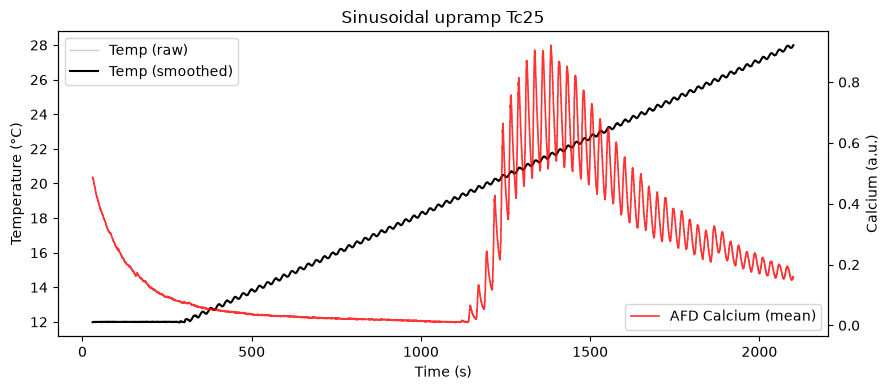

In [26]:
# ==== DROP-IN: virtual reality dataset loader (multi-replicate Rep_*),
#                WITH time-cropping AND Gaussian temp smoothing ====

# -------- USER INPUT ONLY --------
# Dataset: 1 = Tc15, 2 = Tc20, 3 = Tc25
selection = 3

# Match old analysis window
T_START = 30.0
T_END   = 3000.0

# Temperature smoothing (sigma in SAMPLES)
# Recommended: 1–2 for main analysis, try 0,1,2,5 for robustness
TEMP_SMOOTH_SIGMA = 100.0
# ---------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

base_dir = "/Users/sk3526/Library/CloudStorage/OneDrive-YaleUniversity/github_repos/Diaz-Garcia-and-Beagan-et-al.-2026-AFD-/AFD_modeling_Fig_2_5_S4"
    
if selection == 3:
    dataset = "Sinusoidal upramp Tc25"
    filename = "upramp_Tc25.csv"
else:
    raise ValueError("Invalid selection. Please choose 1, 2, or 3.")

file_path = os.path.join(base_dir, filename)
df = pd.read_csv(file_path)

# ---- detect columns robustly ----
time_candidates = [c for c in df.columns if "time" in c.lower()]
temp_candidates = [c for c in df.columns if "temp" in c.lower()]
rep_cols = [c for c in df.columns if c.lower().startswith("rep")]

if len(time_candidates) == 0:
    raise ValueError(f"No time column found. Columns are: {list(df.columns)}")
if len(temp_candidates) == 0:
    raise ValueError(f"No temperature column found. Columns are: {list(df.columns)}")
if len(rep_cols) == 0:
    raise ValueError(f"No Rep_* columns found. Columns are: {list(df.columns)}")

time_col = time_candidates[0]
temp_col = temp_candidates[0]

Time_ramp = df[time_col].to_numpy(dtype=float)
Temp_raw  = df[temp_col].to_numpy(dtype=float)
Ca_mat    = df[rep_cols].to_numpy(dtype=float)  # shape (T, n_reps)

# Drop replicate columns that are all NaN
valid_rep_mask = ~np.all(np.isnan(Ca_mat), axis=0)
Ca_mat = Ca_mat[:, valid_rep_mask]
rep_cols = [c for c, ok in zip(rep_cols, valid_rep_mask) if ok]

# ============================================================
# Crop to stimulus window (CRITICAL)
# ============================================================

if T_END is None:
    mask_time = Time_ramp >= T_START
else:
    mask_time = (Time_ramp >= T_START) & (Time_ramp <= T_END)

if mask_time.sum() < 10:
    raise RuntimeError(
        f"Time crop failed: only {mask_time.sum()} points left. "
        f"Check T_START={T_START}, T_END={T_END}, "
        f"time range=[{Time_ramp.min():.2f}, {Time_ramp.max():.2f}]"
    )

Time_ramp = Time_ramp[mask_time]
Temp_raw  = Temp_raw[mask_time]
Ca_mat    = Ca_mat[mask_time, :]

# ============================================================
# Savitzky–Golay smoothing of temperature (measurement-noise only)
# Window specified in SECONDS (recommended: 3 or 5 s)
# ============================================================

from scipy.signal import savgol_filter

# -------- USER CONTROL --------
TEMP_SMOOTH_WINDOW_SEC = 3.0   # try 3.0 or 5.0
TEMP_SMOOTH_POLYORDER  = 2
# ------------------------------

# Estimate sampling interval
dt = float(np.mean(np.diff(Time_ramp)))

# Convert seconds → samples (must be odd)
win_len = int(round(TEMP_SMOOTH_WINDOW_SEC / dt))
if win_len % 2 == 0:
    win_len += 1
win_len = max(win_len, TEMP_SMOOTH_POLYORDER + 2)

print(f"Savitzky–Golay temp smoothing: window = {win_len} samples "
      f"(~{win_len*dt:.2f} s), polyorder = {TEMP_SMOOTH_POLYORDER}")

# Apply smoothing
Temp_ramp = savgol_filter(
    Temp_raw,
    window_length=win_len,
    polyorder=TEMP_SMOOTH_POLYORDER,
    mode="interp"
)

# ============================================================


n_reps = Ca_mat.shape[1]

print(f"Loaded: {dataset}")
print(f"File: {file_path}")
print(f"Time window: {Time_ramp[0]:.2f} – {Time_ramp[-1]:.2f} s")
print(f"Replicates: {n_reps}")
print(f"Temp smoothing sigma: {TEMP_SMOOTH_SIGMA} samples")
print(f"dt mean = {np.mean(np.diff(Time_ramp)):.4f} s")

# ============================================================
# Quick visualization: Temp (raw vs smoothed) + mean calcium
# ============================================================

Ca_mean = np.nanmean(Ca_mat, axis=1)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(Time_ramp, Temp_raw,  color="gray", alpha=0.4, linewidth=1.0, label="Temp (raw)")
ax1.plot(Time_ramp, Temp_ramp, "k", linewidth=1.5, label="Temp (smoothed)")

ax2.plot(Time_ramp, Ca_mean, "r", alpha=0.8, linewidth=1.2, label="AFD Calcium (mean)")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Calcium (a.u.)")

ax1.legend(loc="upper left")
ax2.legend(loc="lower right")

plt.title(f"{dataset}")
plt.tight_layout()
plt.show()


In [27]:
# ============================================================
# STEPWISE CONCEPTUAL ANALYSIS (Option C), replicate-ready
# UPDATED: removed redundant alpha (absorbed by affine readout)
# ============================================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

TAU_MIN = 1e-2
TAU_MAX = 1e3

def safe_tau(x):
    return float(np.clip(x, TAU_MIN, TAU_MAX))

def one_pole_update(prev, target, dt, tau):
    tau = safe_tau(tau)
    a = 1.0 - np.exp(-dt / tau)
    return prev + a * (target - prev)

def gamma_window(Temp, T_on, k_shape, k_scale):
    Temp = np.asarray(Temp, float)
    T_rel = np.clip(Temp - T_on, 0.0, None)
    W = scipy_gamma.pdf(T_rel, a=k_shape, scale=k_scale)
    mx = np.max(W)
    return W / (mx + 1e-9)

# ---------- UPDATED: no alpha ----------
def simulate_minimal_full(Time, Temp, tauD, T_on, k_shape, k_scale):
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    nT = Time.size
    if nT < 2:
        return np.full_like(Time, np.nan, dtype=float)

    dt = float(np.mean(np.diff(Time)))

    dT_raw = np.zeros(nT, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt

    D_state = np.zeros(nT, dtype=float)
    tauD = safe_tau(tauD)
    for i in range(1, nT):
        D_state[i] = one_pole_update(D_state[i-1], dT_raw[i], dt, tauD)

    # alpha removed: keep raw D_state (scale will be handled by affine readout)
    D = D_state
    W = gamma_window(Temp, T_on, k_shape, k_scale)
    C = D * W
    return C

# ---------- UPDATED: no alpha ----------
def model_1_derivative_gain_only(Time, Temp):
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    nT = Time.size
    if nT < 2:
        return np.full_like(Time, np.nan, dtype=float)
    dt = float(np.mean(np.diff(Time)))
    dT_raw = np.zeros(nT, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt
    return dT_raw

# ---------- UPDATED: no alpha ----------
def model_2_derivative_with_tauD(Time, Temp, tauD):
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    nT = Time.size
    if nT < 2:
        return np.full_like(Time, np.nan, dtype=float)
    dt = float(np.mean(np.diff(Time)))

    dT_raw = np.zeros(nT, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt

    D_state = np.zeros(nT, dtype=float)
    tauD = safe_tau(tauD)
    for i in range(1, nT):
        D_state[i] = one_pole_update(D_state[i-1], dT_raw[i], dt, tauD)

    return D_state

def model_3_full_minimal_gamma(Time, Temp, tauD, T_on, k_shape, k_scale):
    return simulate_minimal_full(Time, Temp, tauD, T_on, k_shape, k_scale)

class MinimalConceptObjective:
    def __init__(self, Time, Temp, Calcium, concept_id):
        self.Time = np.asarray(Time, dtype=float)
        self.Temp = np.asarray(Temp, dtype=float)
        self.Calcium = np.asarray(Calcium, dtype=float)
        self.concept_id = concept_id

        t0 = float(self.Time[0])
        self.mask = self.Time >= (t0 + 10.0)

    def __call__(self, trial):
        if self.concept_id == "deriv_gain":
            C_model = model_1_derivative_gain_only(self.Time, self.Temp)

        elif self.concept_id == "deriv_tau":
            tauD = trial.suggest_float("tauD", 0.5, 100.0, log=True)
            C_model = model_2_derivative_with_tauD(self.Time, self.Temp, tauD)

        elif self.concept_id == "full_gamma":
            tauD    = trial.suggest_float("tauD",    40.0, 60.0, log=True) # 1 to 80
            T_on    = trial.suggest_float("T_on",   20.0, 21.0) #15 to 22
            k_shape = trial.suggest_float("k_shape", 1.5, 8.0)
            k_scale = trial.suggest_float("k_scale", 0.2, 5.0)

            C_model = model_3_full_minimal_gamma(
                self.Time, self.Temp,
                tauD, T_on, k_shape, k_scale
            )
        else:
            return -1e9

        if (not np.all(np.isfinite(C_model))) or (np.nanstd(C_model) < 1e-12):
            return -1e9

        mask = self.mask
        a, b = fit_gain_offset(C_model[mask], self.Calcium[mask])
        if (not np.isfinite(a)) or (not np.isfinite(b)):
            return -1e9

        C_fit = a * C_model + b
        score = r2_nan(self.Calcium[mask], C_fit[mask])
        if not np.isfinite(score):
            return -1e9

        return float(score)

stepwise_concepts = [
    {"id": "deriv_gain", "name": "Model A"},
    {"id": "deriv_tau",  "name": "Model B"},
    {"id": "full_gamma", "name": "Model C"},
]


In [28]:
# ============================================================
# Run stepwise conceptual fits per replicate (Option 2)
# UPDATED:
#   - removed redundant alpha
#   - collect full-gamma best-fit parameters across replicates
#   - NEW: also collect Model B (deriv_tau) best-fit tauD across replicates
# ============================================================

N_TRIALS_PER_MODEL = 300
SEED_BASE = 1

Time = np.asarray(Time_ramp, dtype=float)
Temp = np.asarray(Temp_ramp, dtype=float)

r2_by_concept = {cfg["id"]: [] for cfg in stepwise_concepts}

representative = None
best_full_gamma_r2 = -1e9

# ---- store full-gamma best-fit params across replicates (Model C only) ----
all_full_params = []   # one row per replicate (full model only)

# ---- NEW: store Model B best-fit params across replicates (Model B only) ----
all_modelB_params = []  # one row per replicate (deriv_tau only)

print("\n" + "=" * 70)
print(f"STEPWISE CONCEPTUAL ANALYSIS ACROSS REPLICATES (Option 2) — {dataset}")
print("=" * 70)

# ----------------------------------------------------------------
# QUICK DEBUG KNOB (optional):
#   change Ca_mat.shape[1] -> 1 or 2 for fast tests
# ----------------------------------------------------------------
for rep_idx in range(Ca_mat.shape[1]):
    Calcium = np.asarray(Ca_mat[:, rep_idx], dtype=float)

    if np.isfinite(Calcium).sum() < 10:
        print(f"Replicate {rep_cols[rep_idx]} skipped (too few finite points)")
        for cfg in stepwise_concepts:
            r2_by_concept[cfg["id"]].append(np.nan)
        continue

    rep_name = str(rep_cols[rep_idx])
    print(f"\nReplicate {rep_idx + 1}/{Ca_mat.shape[1]}: {rep_name}")

    rep_results = []

    for cfg in stepwise_concepts:
        cid = cfg["id"]
        cname = cfg["name"]

        seed_val = stable_seed(dataset, rep_name, cid, base=SEED_BASE)
        set_all_seeds(seed_val)

        sampler = optuna.samplers.TPESampler(seed=seed_val)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        objective = MinimalConceptObjective(Time, Temp, Calcium, concept_id=cid)

        study.optimize(
            objective,
            n_trials=N_TRIALS_PER_MODEL,
            show_progress_bar=True,
            n_jobs=1
        )

        best_params = dict(study.best_params)   # empty dict for deriv_gain
        mask = objective.mask

        # ---- build model output ----
        if cid == "deriv_gain":
            C_model = model_1_derivative_gain_only(Time, Temp)

        elif cid == "deriv_tau":
            C_model = model_2_derivative_with_tauD(Time, Temp, **best_params)

        elif cid == "full_gamma":
            C_model = model_3_full_minimal_gamma(Time, Temp, **best_params)

        else:
            C_model = np.full_like(Time, np.nan, dtype=float)

        # ---- affine readout ----
        a, b = fit_gain_offset(C_model[mask], Calcium[mask])
        C_fit = a * C_model + b
        R2 = r2_nan(Calcium[mask], C_fit[mask])

        r2_by_concept[cid].append(R2)

        rep_results.append({
            "id": cid,
            "name": cname,
            "R2": R2,
            "fit": C_fit,
            "params": best_params,
            "a": a,
            "b": b,
        })

        print(f"  {cname}: R2 = {R2:.4f}")

        # ========================================================
        # NEW: collect Model B (deriv_tau) best-fit params for LN-test plots
        # ========================================================
        if cid == "deriv_tau" and np.isfinite(R2):
            rowB = {
                "rep_name": rep_name,
                "rep_idx": int(rep_idx),
                "R2": float(R2),
            }
            for k, v in best_params.items():   # should include tauD
                rowB[k] = float(v)
            all_modelB_params.append(rowB)

        # ========================================================
        # collect FULL MODEL (gamma) parameters for spread plots
        # ========================================================
        if cid == "full_gamma" and np.isfinite(R2):
            row = {
                "rep_name": rep_name,
                "rep_idx": int(rep_idx),
                "R2": float(R2),
            }
            for k, v in best_params.items():
                row[k] = float(v)
            all_full_params.append(row)

    # ---- track representative replicate (best full model R2) ----
    full_entry = next((r for r in rep_results if r["id"] == "full_gamma"), None)
    full_r2 = np.nan if full_entry is None else full_entry["R2"]

    if np.isfinite(full_r2) and (full_r2 > best_full_gamma_r2):
        best_full_gamma_r2 = float(full_r2)
        representative = {
            "rep_name": rep_name,
            "rep_idx": rep_idx,
            "Calcium": Calcium,
            "results": rep_results
        }

print("\nDone. Replicate counts per concept:")
for cfg in stepwise_concepts:
    arr = np.asarray(r2_by_concept[cfg["id"]], dtype=float)
    print(f"  {cfg['name']}: n={np.isfinite(arr).sum()}/{arr.size}")

print(f"\nCollected full-model parameter sets: {len(all_full_params)}")
print(f"Collected Model B parameter sets: {len(all_modelB_params)}")



STEPWISE CONCEPTUAL ANALYSIS ACROSS REPLICATES (Option 2) — Sinusoidal upramp Tc25

Replicate 1/17: Rep_1


  0%|          | 0/300 [00:00<?, ?it/s]

  Model A: R2 = 0.0017


  0%|          | 0/300 [00:00<?, ?it/s]

  Model B: R2 = 0.0497


...

  Model A: R2 = 0.0057


  0%|          | 0/300 [00:00<?, ?it/s]

  Model B: R2 = 0.0809


  0%|          | 0/300 [00:00<?, ?it/s]

  Model C: R2 = 0.9504

Done. Replicate counts per concept:
  Model A: n=17/17
  Model B: n=17/17
  Model C: n=17/17

Collected full-model parameter sets: 17
Collected Model B parameter sets: 17


In [29]:
# ---- PRINT ONLY the REPRESENTATIVE replicate's FULL (gamma) model best-fit params (2 decimals) ----
if representative is None:
    print("No representative replicate available.")
else:
    rep_name = str(representative["rep_name"])
    rep_results = representative["results"]

    # pick full model entry from the representative replicate
    full_res = next((r for r in rep_results if r.get("id") == "full_gamma"), None)
    if full_res is None:
        full_res = rep_results[-1]  # fallback if ordering is fixed

    params = full_res["params"]

    print("\n" + "=" * 70)
    print(f"Representative replicate: {rep_name}  |  Dataset: {dataset}")
    print(f"FULL MODEL (gamma): {full_res['name']}")
    print(f"R² (representative, full model) = {full_res['R2']:.2f}")

    print("Best-fit parameters (Optuna):")
    if len(params) == 0:
        print("  (none)")
    else:
        for k, v in params.items():
            if isinstance(v, (float, np.floating)):
                print(f"  {k} = {v:.2f}")
            else:
                print(f"  {k} = {v}")

    print(f"Readout (gain/offset): a = {full_res['a']:.2f},  b = {full_res['b']:.2f}")

    # Explicit gamma params
    kshape = params.get("k_shape")
    kscale = params.get("k_scale")
    if kshape is not None and kscale is not None:
        print(f"Gamma params: k_shape = {kshape:.2f},  k_scale = {kscale:.2f}")

    print("=" * 70 + "\n")



Representative replicate: Rep_17  |  Dataset: Sinusoidal upramp Tc25
FULL MODEL (gamma): Model C
R² (representative, full model) = 0.95
Best-fit parameters (Optuna):
  tauD = 55.47
  T_on = 20.00
  k_shape = 1.50
  k_scale = 2.61
Readout (gain/offset): a = 79.56,  b = 0.05
Gamma params: k_shape = 1.50,  k_scale = 2.61



Saved bar plot to: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/model_R2_Sinusoidal upramp Tc25.svg


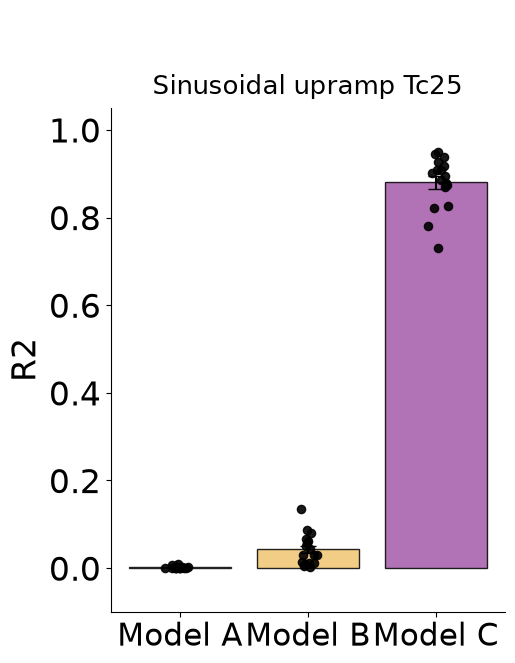

Saved timeseries plot to: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/model_fits_Sinusoidal upramp Tc25_Rep_17.svg


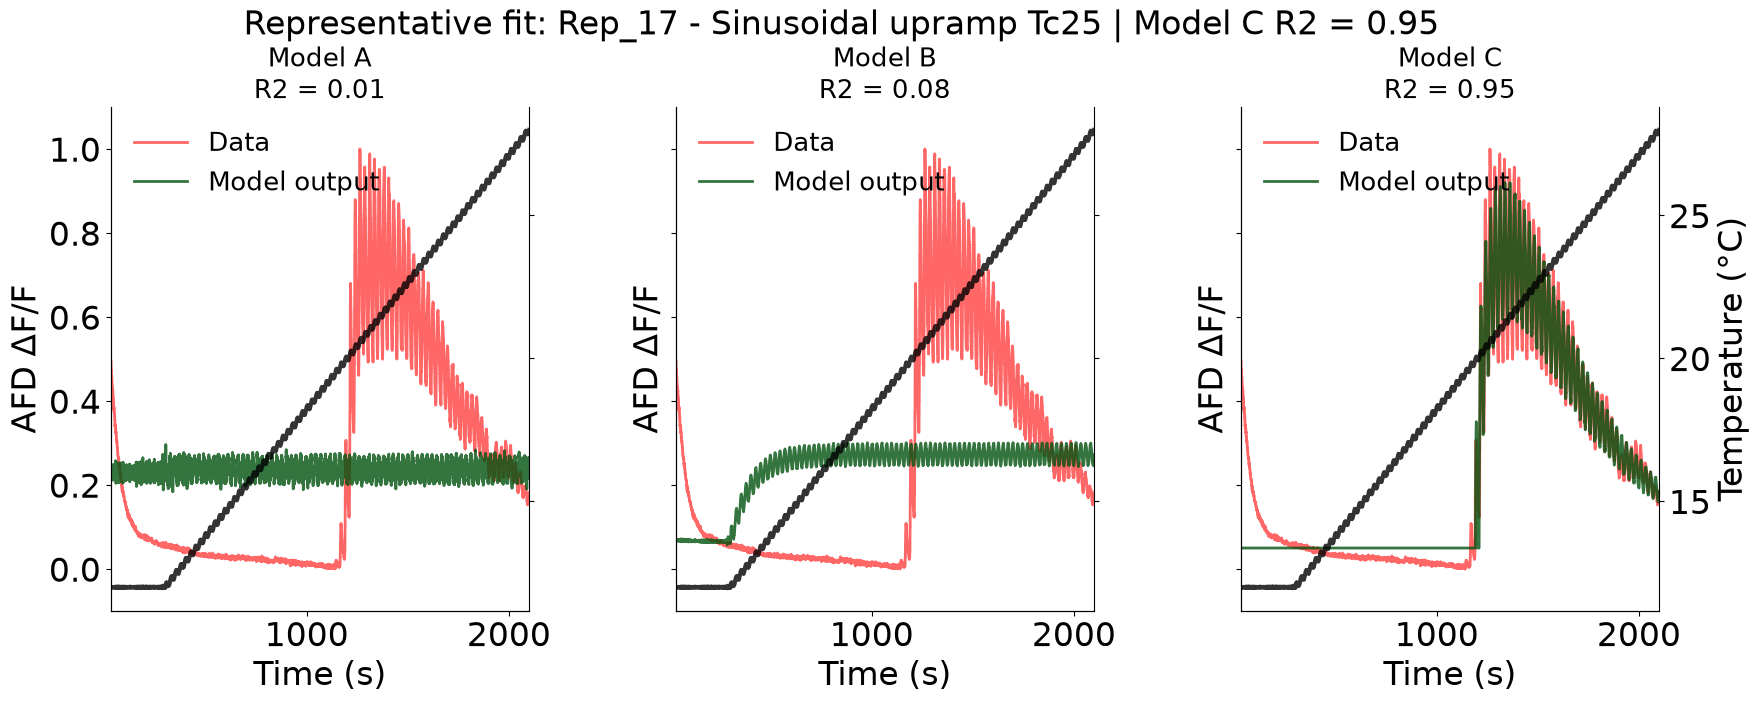

In [30]:
# ============================================================
# Visualizations: mean ± SEM R2 bars, plus representative timeseries
# PLUS parameter diagnostics (3 plots)
# UPDATED (your request):
#  - Parameter diagnostics now use FIXED axis limits equal to your Optuna ranges
#    so you can compare across conditions (Tc15/Tc20/Tc25, etc.)
#      * Violin plot: y-lims fixed to parameter range
#      * Param vs R2: x-lims fixed to parameter range (R2 y-lims unchanged)
#      * Pairplot: x/y-lims fixed to parameter ranges for all panels (including diagonal)
#  - Plot 1 + Plot 2 (parameter diagnostics) are SAVED (SVG) like others
#  - Pairplot is saved correctly (SAVE happens BEFORE plt.show so it never gets blank)
#  - No redundant imports, consistent RNG usage
#  - Preserves your locked-margin workflow for bar + timeseries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import pandas as pd
import seaborn as sns

# ---- Illustrator-safe SVG settings ----
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["svg.hashsalt"] = "0"

SAVE_FIGURES = True
SAVE_DIR = r"/Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp"
FIGURE_PREFIX = "model"

BAR_YLIM = (-0.1, 1.05)

# ---- Colorblind-friendlier colors ----
DATA_COLOR = "#ff0101"   # Pink
FIT_COLOR  = "#00510f"   # Teal
TEMP_COLOR = "black"

DATA_ALPHA = 0.6
FIT_ALPHA  = 0.8
TEMP_ALPHA = 0.8

LINE_WIDTH = 2
TEMP_LINE_WIDTH = 1.5 * LINE_WIDTH

# ---- Match bar-plot size to timeseries panel geometry ----
PANEL_W = 5.8
PANEL_H = 7.0
BAR_W   = PANEL_W
BAR_H   = PANEL_H

# ---- Font sizes for bar + timeseries ----
SCALE = 1.2
TS_TITLE_FS   = int(round(16 * SCALE))
TS_LABEL_FS   = int(round(20 * SCALE))
TS_TICK_FS    = int(round(20 * SCALE))
TS_LEGEND_FS  = int(round(16 * SCALE))
SUPTITLE_FS   = int(round(20 * SCALE))

BAR_YTICK_FS  = TS_TICK_FS
BAR_YLABEL_FS = TS_LABEL_FS
BAR_TITLE_FS  = TS_TITLE_FS
BAR_XTICK_FS  = int(round(TS_TICK_FS * 0.9))  # only x-ticks smaller to prevent overlap

# ---- Parameter diagnostics font bump ----
P3_SCALE        = 1.45
P3_LABEL_FS     = int(round(16 * P3_SCALE))
P3_TICK_FS      = int(round(14 * P3_SCALE))
P3_TITLE_FS     = int(round(18 * P3_SCALE))
P3_SUPTITLE_FS  = int(round(20 * P3_SCALE))

# ---- Locked margins (critical for PPT/Illustrator matching) ----
TOP    = 0.88
BOTTOM = 0.16

LEFT_BAR  = 0.30
RIGHT_BAR = 0.98

LEFT_TS   = 0.08
RIGHT_TS  = 0.97
WSPACE_TS = 0.35

# ---- FIXED parameter ranges (match Optuna priors) ----
PARAM_RANGES = {
    "tauD":    (40.0, 60.0),
    "T_on":    (20.0, 21.0),
    "k_shape": (1.5, 8.0),
    "k_scale": (0.2, 5.0),
}

# ---- helpers ----
def mean_sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    if x.size == 1:
        return x[0], 0.0
    return x.mean(), x.std(ddof=1) / np.sqrt(x.size)

def _floor_half(x):
    return 0.5 * np.floor(x / 0.5)

def _ceil_half(x):
    return 0.5 * np.ceil(x / 0.5)

def compute_ylim_from_traces_strict(traces):
    """
    y-limits snapped to 0.5 grid with strict enclosure:
      lo = closest LOWER multiple of 0.5 BELOW min
      hi = closest HIGHER multiple of 0.5 ABOVE max
    """
    finite = []
    for t in traces:
        t = np.asarray(t, dtype=float)
        t = t[np.isfinite(t)]
        if t.size:
            finite.append(t)

    if not finite:
        return (-0.5, 0.5)

    vmin = float(min(np.min(v) for v in finite))
    vmax = float(max(np.max(v) for v in finite))

    lo = _floor_half(vmin)
    hi = _ceil_half(vmax)

    # strict enclosure if exactly on boundary
    if np.isclose(lo, vmin):
        lo -= 0.5
    if np.isclose(hi, vmax):
        hi += 0.5

    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (hi <= lo):
        return (-0.5, 0.5)

    return (lo, hi)

def apply_pairplot_param_ranges(g, param_order, param_ranges):
    """
    Enforce fixed x/y limits on a seaborn pairplot grid, including diagonal.
    """
    for i, yvar in enumerate(param_order):
        for j, xvar in enumerate(param_order):
            ax = g.axes[i, j]
            if ax is None:
                continue
            if xvar in param_ranges:
                ax.set_xlim(param_ranges[xvar])
            if yvar in param_ranges:
                ax.set_ylim(param_ranges[yvar])

# Make sure save directory exists if saving
if SAVE_FIGURES:
    os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# A. Bar plot
# ============================================================

model_names = [cfg["name"] for cfg in stepwise_concepts]
concept_ids = [cfg["id"] for cfg in stepwise_concepts]

r2_arrays = [np.asarray(r2_by_concept[cid], dtype=float) for cid in concept_ids]
means = np.array([mean_sem(a)[0] for a in r2_arrays])
sems  = np.array([mean_sem(a)[1] for a in r2_arrays])

x = np.arange(len(concept_ids))
BAR_COLORS = ["#b8b8b8", "#f0c571", "#a559aa"][:len(concept_ids)]

fig_bar, ax = plt.subplots(figsize=(BAR_W, BAR_H))

ax.bar(
    x, means, yerr=sems, capsize=6,
    color=BAR_COLORS, edgecolor="black",
    linewidth=1.0, alpha=0.85, ecolor="black"
)

rng = np.random.default_rng(0)
for i, arr in enumerate(r2_arrays):
    v = arr[np.isfinite(arr)]
    jitter = rng.normal(0.0, 0.05, size=v.size)
    ax.scatter(np.full(v.size, x[i]) + jitter, v,
               color="black", s=35, alpha=0.9, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=BAR_XTICK_FS)
ax.set_ylabel("R2", fontsize=BAR_YLABEL_FS)
ax.set_title(f"{dataset}", fontsize=BAR_TITLE_FS, pad=10)
ax.tick_params(axis="y", labelsize=BAR_YTICK_FS)
ax.set_ylim(BAR_YLIM)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig_bar.suptitle(" ", fontsize=SUPTITLE_FS, y=1.02)
fig_bar.subplots_adjust(left=LEFT_BAR, right=RIGHT_BAR, bottom=BOTTOM, top=TOP)

if SAVE_FIGURES:
    save_path = os.path.join(SAVE_DIR, f"{FIGURE_PREFIX}_R2_{dataset}.svg")
    fig_bar.savefig(save_path, format="svg")
    print(f"Saved bar plot to: {save_path}")

plt.show()

# ============================================================
# B. Representative timeseries  (UPDATED: add per-model R2 in each panel title)
# ============================================================

if representative is None:
    print("No representative replicate available for timeseries plot.")
else:
    Time = np.asarray(Time_ramp, dtype=float)
    Temp = np.asarray(Temp_ramp, dtype=float)

    Calcium = np.asarray(representative["Calcium"], dtype=float)
    rep_name = str(representative["rep_name"])
    rep_results = representative["results"]

    # y_limits = compute_ylim_from_traces_strict([Calcium] + [r["fit"] for r in rep_results if "fit" in r])
    y_limits = (-0.1, 1.1)   # FIXED y-limits for consistency

    fig_ts, axes = plt.subplots(
        1, len(rep_results),
        figsize=(PANEL_W * len(rep_results), PANEL_H),
        sharey=True
    )
    if len(rep_results) == 1:
        axes = [axes]

    temp_axes = []

    for axC, res in zip(axes, rep_results):
        # ---- plot data + model fit ----
        axC.plot(Time, Calcium, color=DATA_COLOR, alpha=DATA_ALPHA,
                 linewidth=LINE_WIDTH, label="Data", zorder=2)

        axC.plot(Time, np.asarray(res["fit"], dtype=float),
                 color=FIT_COLOR, alpha=FIT_ALPHA,
                 linewidth=LINE_WIDTH, label="Model output", zorder=3)

        # ---- UPDATED: add R2 into panel title ----
        r2_txt = "R2 = n/a"
        if "R2" in res and np.isfinite(res["R2"]):
            r2_txt = f"R2 = {res['R2']:.2f}"

        axC.set_title(f"{res['name']}\n{r2_txt}", fontsize=TS_TITLE_FS)

        axC.set_xlabel("Time (s)", fontsize=TS_LABEL_FS)
        axC.set_ylabel("AFD ΔF/F", fontsize=TS_LABEL_FS)
        axC.tick_params(axis="both", labelsize=TS_TICK_FS)
        axC.set_xlim(Time[0], Time[-1])
        axC.set_ylim(y_limits)

        axC.spines["top"].set_visible(False)
        axC.spines["right"].set_visible(False)

        # ---- temperature overlay ----
        axT = axC.twinx()
        temp_axes.append(axT)
        axT.plot(Time, Temp, color=TEMP_COLOR, alpha=TEMP_ALPHA,
                 linewidth=TEMP_LINE_WIDTH, zorder=1)
        axT.tick_params(axis="y", labelsize=TS_TICK_FS, labelright=False)
        axT.spines["top"].set_visible(False)

        # ---- legend ----
        hC, lC = axC.get_legend_handles_labels()
        hT, lT = axT.get_legend_handles_labels()
        axC.legend(hC + hT, lC + lT,
                   fontsize=TS_LEGEND_FS, loc="upper left", frameon=False)

    temp_axes[-1].tick_params(axis="y", labelright=True, labelsize=TS_TICK_FS)
    temp_axes[-1].set_ylabel("Temperature (°C)", fontsize=TS_LABEL_FS)

    # ---- UPDATED: put overall full-model R2 in the suptitle too ----
    full_r2_txt = ""
    full_entry = next((r for r in rep_results if r.get("id") == "full_gamma"), None)
    if full_entry is not None and np.isfinite(full_entry.get("R2", np.nan)):
        full_r2_txt = f" | Model C R2 = {full_entry['R2']:.2f}"

    fig_ts.suptitle(
        f"Representative fit: {rep_name} - {dataset}{full_r2_txt}",
        fontsize=SUPTITLE_FS, y=1.02
    )

    fig_ts.subplots_adjust(
        left=LEFT_TS, right=RIGHT_TS,
        bottom=BOTTOM, top=TOP, wspace=WSPACE_TS
    )

    if SAVE_FIGURES:
        save_path = os.path.join(SAVE_DIR, f"{FIGURE_PREFIX}_fits_{dataset}_{rep_name}.svg")
        fig_ts.savefig(save_path, format="svg")
        print(f"Saved timeseries plot to: {save_path}")

    plt.show()

# ============================================================


Selected random worm/replicate: 14
LN-test points collected (worm 14): 20600
Saved figure to: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/model_R2_Sinusoidal upramp Tc25_LNtest.svg


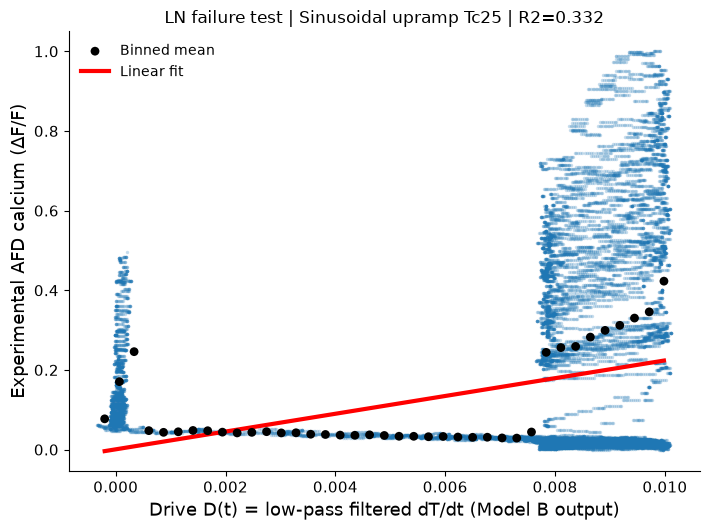

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# Single random worm (replicate): Calcium vs Drive D
# LN-style binned mean + linear fit
# Saves figure only if SAVE_FIGURES = False
# ============================================================

# ---------------- USER CONTROLS ----------------
USE_ALL_REPS = True
REP_TO_USE = 0

N_RANDOM_WORMS = 1
RANDOM_SEED = 0

DROP_INITIAL_SECONDS = 10.0

SUBSAMPLE_MAX_POINTS = 60000
SCATTER_S = 6
SCATTER_ALPHA = 0.25

# LN-style summary settings
N_D_BINS_LN = 40
MIN_POINTS_PER_BIN = 20
SUMMARY_POINT_SIZE = 40

# Figure saving
# ------------------------------------------------------------

# Safety checks
if "all_modelB_params" not in globals() or len(all_modelB_params) == 0:
    raise RuntimeError(
        "all_modelB_params is missing or empty."
    )

dfB = pd.DataFrame(all_modelB_params).copy()
if "tauD" not in dfB.columns:
    raise RuntimeError("tauD not found.")
if "rep_idx" not in dfB.columns:
    raise RuntimeError("rep_idx not found.")

Time = np.asarray(Time_ramp, dtype=float)
Temp = np.asarray(Temp_ramp, dtype=float)
t0 = float(Time[0])
mask0 = Time >= (t0 + float(DROP_INITIAL_SECONDS))

def compute_D_from_tau(Time, Temp, tauD):
    return model_2_derivative_with_tauD(Time, Temp, tauD)

# Decide reps
if USE_ALL_REPS:
    rep_indices = list(range(Ca_mat.shape[1]))
else:
    rep_indices = [int(REP_TO_USE)]

tauD_by_rep = {int(row["rep_idx"]): float(row["tauD"]) for _, row in dfB.iterrows()}

valid_reps = [r for r in rep_indices if r in tauD_by_rep]
if len(valid_reps) == 0:
    raise RuntimeError("No valid replicates found.")

# Pick random worm
rng = np.random.default_rng(RANDOM_SEED)
rep_idx = int(rng.choice(valid_reps, size=1, replace=False)[0])
print(f"Selected random worm/replicate: {rep_idx}")

# Data extraction
Calcium = np.asarray(Ca_mat[:, rep_idx], dtype=float)
tauD = float(tauD_by_rep[rep_idx])
D = compute_D_from_tau(Time, Temp, tauD)

m = mask0 & np.isfinite(D) & np.isfinite(Calcium)
if np.sum(m) < 20:
    raise RuntimeError("Too few valid points.")

D_all = D[m]
Ca_all = Calcium[m]

print(f"LN-test points collected (worm {rep_idx}): {len(D_all)}")

# Subsample for plotting
n = len(D_all)
if (SUBSAMPLE_MAX_POINTS is not None) and (n > SUBSAMPLE_MAX_POINTS):
    rng2 = np.random.default_rng(0)
    idx = rng2.choice(n, size=int(SUBSAMPLE_MAX_POINTS), replace=False)
    D_plot  = D_all[idx]
    Ca_plot = Ca_all[idx]
else:
    D_plot  = D_all
    Ca_plot = Ca_all

# -------------------------
# LN-style binning
# -------------------------
bins = np.linspace(np.nanmin(D_all), np.nanmax(D_all), int(N_D_BINS_LN))
bin_centers = 0.5 * (bins[:-1] + bins[1:])

Ca_mean = np.full(len(bin_centers), np.nan)
bin_counts = np.zeros(len(bin_centers), dtype=int)

for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mk = (D_all >= lo) & (D_all < hi) & np.isfinite(Ca_all)
    bin_counts[k] = np.sum(mk)
    if bin_counts[k] >= MIN_POINTS_PER_BIN:
        Ca_mean[k] = np.nanmean(Ca_all[mk])

# Linear fit
fit_mask = np.isfinite(bin_centers) & np.isfinite(Ca_mean)

if np.sum(fit_mask) >= 2:
    x_fit = bin_centers[fit_mask]
    y_fit = Ca_mean[fit_mask]

    a, b = np.polyfit(x_fit, y_fit, deg=1)
    y_pred = a * x_fit + b

    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
    R2 = np.nan if ss_tot == 0 else (1.0 - ss_res / ss_tot)
else:
    a, b, R2 = np.nan, np.nan, np.nan

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.4))

# Scatter in standard matplotlib blue
ax.scatter(
    D_plot, Ca_plot,
    s=SCATTER_S,
    alpha=SCATTER_ALPHA,
    color="#1f77b4",
    linewidths=0
)

# Binned means
ax.scatter(
    bin_centers[fit_mask], Ca_mean[fit_mask],
    s=SUMMARY_POINT_SIZE,
    c="black",
    edgecolors="none",
    zorder=5,
    label="Binned mean"
)

# Linear fit
if np.isfinite(a):
    x_line = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 200)
    y_line = a * x_line + b
    ax.plot(x_line, y_line, color="red", linewidth=3.0, label="Linear fit")

ax.set_xlabel("Drive D(t) = low-pass filtered dT/dt (Model B output)", fontsize=13)
ax.set_ylabel("Experimental AFD calcium (ΔF/F)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

# -------- Title (updated format) --------
r2_str = "NA" if not np.isfinite(R2) else f"{R2:.3f}"
ax.set_title(f"LN failure test | {dataset} | R2={r2_str}", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()

# -------------------------
# Save figure (same naming style as your pipeline)
# -------------------------
if SAVE_FIGURES:
    os.makedirs(SAVE_DIR, exist_ok=True)

    r2_tag = "NA" if not np.isfinite(R2) else f"{R2:.3f}"
    save_path = os.path.join(
        SAVE_DIR,
        f"{FIGURE_PREFIX}_R2_{dataset}_LNtest.svg"
    )

    fig.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"Saved figure to: {save_path}")

plt.show()



# Reviewer 3 cross-validation analysis (added)

This section was added to address Reviewer 3's concern that the model parameters may have been overfit animal-by-animal.

The original analysis above is unchanged. This new section performs worm-level cross-validation:

1. Split worms/replicates into training and test sets.
2. Fit the **biological model parameters** using only the training worms.
3. Freeze those biological parameters.
4. Predict the held-out test worms.
5. For each held-out worm, fit only the affine readout parameters `a` and `b` because these account for worm-to-worm fluorescence scale and baseline differences, not the biological temperature-processing model.

Thus, the held-out R² tests whether the model's predicted **timecourse shape** generalizes to unseen worms.



REVIEWER 3 WORM-LEVEL CROSS-VALIDATION — Sinusoidal upramp Tc25
Worms/replicates: 17
CV mode: kfold; folds: 5
Optuna trials per train fold/model: 300
Biological parameters are fit on training worms and frozen for test worms.
For each test worm, only nuisance affine readout a,b is fit before calculating held-out R².
No figures are saved by this cell. SAVE_CV_FIGURES = False

Fold 1/5 | train n=13 | test n=4
  Model A: train mean R²=0.0018; test mean R²=0.0020; params={}
  Model B: train mean R²=0.0418; test mean R²=0.0437; params={'tauD': 99.99697080893648}
  Model C: train mean R²=0.8271; test mean R²=0.8135; params={'tauD': 44.210683879837845, 'T_on': 20.117289495383453, 'k_shape': 1.7764155020092678, 'k_scale': 1.820078997955987}

Fold 2/5 | train n=13 | test n=4
  Model A: train mean R²=0.0023; test mean R²=0.0004; params={}
  Model B: train mean R²=0.0444; test mean R²=0.0351; params={'tauD': 99.99918272641725}
  Model C: train mean R²=0.8202; test mean R²=0.8399; params={'tauD': 

,model_id,model_name,n,mean_R2,median_R2,std_R2,sem_R2
2,full_gamma,Model C,17,0.816818,0.836794,0.092317,0.022390
1,deriv_tau,Model B,17,0.042240,0.030063,0.036264,0.008795
0,deriv_gain,Model A,17,0.001840,0.000738,0.002625,0.000637



Best-fit shared biological parameters per fold:


,fold,model_id,model_name,train_n,test_n,train_mean_R2_objective,test_mean_R2,tauD,T_on,k_shape,k_scale
0,1,deriv_gain,Model A,13,4,0.001785,0.002019,NaN,NaN,NaN,NaN
1,1,deriv_tau,Model B,13,4,0.041784,0.043732,99.996971,NaN,NaN,NaN
2,1,full_gamma,Model C,13,4,0.827071,0.813474,44.210684,20.117289,1.776416,1.820079
3,2,deriv_gain,Model A,13,4,0.002274,0.000431,NaN,NaN,NaN,NaN
4,2,deriv_tau,Model B,13,4,0.044437,0.035112,99.999183,NaN,NaN,NaN
5,2,full_gamma,Model C,13,4,0.820239,0.839909,41.796279,20.001868,1.770858,1.988527
6,3,deriv_gain,Model A,14,3,0.001993,0.001127,NaN,NaN,NaN,NaN
7,3,deriv_tau,Model B,14,3,0.042947,0.038951,99.993010,NaN,NaN,NaN
8,3,full_gamma,Model C,14,3,0.824525,0.820850,50.735826,20.030945,1.705514,1.912157
9,4,deriv_gain,Model A,14,3,0.001796,0.002047,NaN,NaN,NaN,NaN



Paired held-out comparisons against Model C:


,comparison,n_paired_worms,mean_delta_R2,median_delta_R2,wilcoxon_p
0,Model C - deriv_gain,17,0.814978,0.836684,0.000015
1,Model C - deriv_tau,17,0.774579,0.774742,0.000015


Saved SVG: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/sinusoidal_upramp_auto_005_Sinusoidal_upramp_Tc25.svg


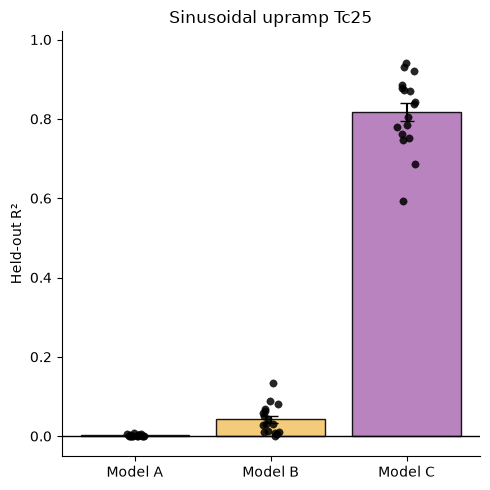


Interpretation note:
- Model parameters reported in cv_param_df are shared biological parameters fit only on training worms.
- Test R² values use those frozen biological parameters on held-out worms.
- Per-worm a,b are fit in the held-out set only as nuisance fluorescence scale/offset parameters.


In [32]:

# ============================================================
# REVIEWER 3: worm-level cross-validation
# Train biological parameters on a subset of worms, then test
# on held-out worms with biological parameters frozen.
#
# Important: a,b are refit per held-out worm because they are
# nuisance fluorescence readout parameters (scale + offset), not
# biological sensory-processing parameters.
#
# This cell does NOT save any figures.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import wilcoxon

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------- USER CONTROLS ----------------
CV_MODE = "kfold"          # "kfold" or "loo"
N_SPLITS_CV = 5             # used only if CV_MODE="kfold"
N_TRIALS_CV = 300           # increase to 300+ for final reviewer numbers
RANDOM_SEED_CV = 1
DROP_INITIAL_SECONDS_CV = 10.0
SHOW_OPTUNA_PROGRESS_CV = False
PLOT_CV_RESULTS = True      # show figure in notebook only
SAVE_CV_FIGURES = False     # keep False; no figures are saved
# ------------------------------------------------

# Safety checks
required_names = [
    "Time_ramp", "Temp_ramp", "Ca_mat", "rep_cols",
    "fit_gain_offset", "r2_nan",
    "model_1_derivative_gain_only",
    "model_2_derivative_with_tauD",
    "model_3_full_minimal_gamma",
    "stable_seed", "set_all_seeds",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Run the earlier notebook cells first. Missing: {missing}")

Time_cv = np.asarray(Time_ramp, dtype=float)
Temp_cv = np.asarray(Temp_ramp, dtype=float)
Ca_cv = np.asarray(Ca_mat, dtype=float)
n_reps_cv = int(Ca_cv.shape[1])

if n_reps_cv < 3:
    raise RuntimeError(f"Need at least 3 worms/replicates for cross-validation; found {n_reps_cv}.")

mask_cv = Time_cv >= (float(Time_cv[0]) + float(DROP_INITIAL_SECONDS_CV))
if np.sum(mask_cv) < 10:
    raise RuntimeError("Too few time points after DROP_INITIAL_SECONDS_CV.")

# Keep the same three models as the original notebook.
# Model A: raw derivative only; no biological parameters.
# Model B: leaky derivative; shared tauD fit on training worms.
# Model C: leaky derivative + Gamma gain window; shared tauD, T_on, k_shape, k_scale fit on training worms.
cv_model_configs = [
    {"id": "deriv_gain", "name": "Model A", "description": "Derivative only"},
    {"id": "deriv_tau",  "name": "Model B", "description": "Leaky derivative"},
    {"id": "full_gamma", "name": "Model C", "description": "Leaky derivative + Gamma gain"},
]


def _build_model_for_cv(model_id, params):
    """Return latent model trace C(t) from frozen biological parameters."""
    if model_id == "deriv_gain":
        return model_1_derivative_gain_only(Time_cv, Temp_cv)
    if model_id == "deriv_tau":
        return model_2_derivative_with_tauD(Time_cv, Temp_cv, tauD=float(params["tauD"]))
    if model_id == "full_gamma":
        return model_3_full_minimal_gamma(
            Time_cv, Temp_cv,
            tauD=float(params["tauD"]),
            T_on=float(params["T_on"]),
            k_shape=float(params["k_shape"]),
            k_scale=float(params["k_scale"]),
        )
    raise ValueError(f"Unknown model_id: {model_id}")


def _suggest_params_for_cv(trial, model_id):
    """Use the same parameter ranges as the original per-replicate analysis."""
    if model_id == "deriv_gain":
        return {}
    if model_id == "deriv_tau":
        return {
            "tauD": trial.suggest_float("tauD", 0.5, 100.0, log=True),
        }
    if model_id == "full_gamma":
        return {
            "tauD":    trial.suggest_float("tauD",    40.0, 60.0, log=True),
            "T_on":    trial.suggest_float("T_on",    20.0, 21.0),
            "k_shape": trial.suggest_float("k_shape", 1.5, 8.0),
            "k_scale": trial.suggest_float("k_scale", 0.2, 5.0),
        }
    raise ValueError(f"Unknown model_id: {model_id}")


def _eval_worms_with_affine(C_model, worm_indices):
    """
    Evaluate one latent model trace on a list of worms.
    For each worm, fit its own a,b and then calculate R².
    This matches the original affine readout strategy, while keeping
    biological parameters fixed across worms.
    """
    rows = []
    C_model = np.asarray(C_model, dtype=float)
    if (not np.all(np.isfinite(C_model))) or (np.nanstd(C_model[mask_cv]) < 1e-12):
        for rep_idx in worm_indices:
            rows.append({"rep_idx": int(rep_idx), "a": np.nan, "b": np.nan, "R2": np.nan})
        return rows

    for rep_idx in worm_indices:
        Calcium = np.asarray(Ca_cv[:, int(rep_idx)], dtype=float)
        a, b = fit_gain_offset(C_model[mask_cv], Calcium[mask_cv])
        if (not np.isfinite(a)) or (not np.isfinite(b)):
            R2 = np.nan
        else:
            pred = a * C_model + b
            R2 = r2_nan(Calcium[mask_cv], pred[mask_cv])
        rows.append({"rep_idx": int(rep_idx), "a": float(a), "b": float(b), "R2": float(R2) if np.isfinite(R2) else np.nan})
    return rows


def _mean_r2_for_worms(C_model, worm_indices):
    rows = _eval_worms_with_affine(C_model, worm_indices)
    vals = np.array([row["R2"] for row in rows], dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -1e9
    return float(np.mean(vals))


def _fit_shared_biological_params(model_id, train_indices, fold_id):
    """
    Fit biological parameters shared across all training worms.
    a,b are still fit separately for each training worm inside the objective.
    """
    if model_id == "deriv_gain":
        C_model = _build_model_for_cv(model_id, {})
        train_score = _mean_r2_for_worms(C_model, train_indices)
        return {}, train_score

    def objective(trial):
        params = _suggest_params_for_cv(trial, model_id)
        C_model = _build_model_for_cv(model_id, params)
        score = _mean_r2_for_worms(C_model, train_indices)
        if not np.isfinite(score):
            return -1e9
        return float(score)

    seed_val = stable_seed(dataset, "reviewer3_cv", model_id, fold_id, base=RANDOM_SEED_CV)
    set_all_seeds(seed_val)
    sampler = optuna.samplers.TPESampler(seed=seed_val)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(
        objective,
        n_trials=int(N_TRIALS_CV),
        show_progress_bar=bool(SHOW_OPTUNA_PROGRESS_CV),
        n_jobs=1,
    )
    return dict(study.best_params), float(study.best_value)


def _make_cv_folds(n_reps, mode="kfold", n_splits=5, seed=1):
    all_idx = np.arange(n_reps, dtype=int)
    rng = np.random.default_rng(int(seed))
    shuffled = all_idx.copy()
    rng.shuffle(shuffled)

    if str(mode).lower() == "loo":
        folds = []
        for rep_idx in shuffled:
            test_idx = np.array([rep_idx], dtype=int)
            train_idx = np.setdiff1d(all_idx, test_idx)
            folds.append((train_idx, test_idx))
        return folds

    n_splits = int(min(max(2, n_splits), n_reps))
    test_groups = np.array_split(shuffled, n_splits)
    folds = []
    for test_idx in test_groups:
        test_idx = np.asarray(test_idx, dtype=int)
        train_idx = np.setdiff1d(all_idx, test_idx)
        folds.append((train_idx, test_idx))
    return folds


cv_folds = _make_cv_folds(n_reps_cv, CV_MODE, N_SPLITS_CV, RANDOM_SEED_CV)
print("\n" + "=" * 78)
print(f"REVIEWER 3 WORM-LEVEL CROSS-VALIDATION — {dataset}")
print("=" * 78)
print(f"Worms/replicates: {n_reps_cv}")
print(f"CV mode: {CV_MODE}; folds: {len(cv_folds)}")
print(f"Optuna trials per train fold/model: {N_TRIALS_CV}")
print("Biological parameters are fit on training worms and frozen for test worms.")
print("For each test worm, only nuisance affine readout a,b is fit before calculating held-out R².")
print("No figures are saved by this cell. SAVE_CV_FIGURES =", SAVE_CV_FIGURES)

cv_rows = []
cv_param_rows = []

for fold_id, (train_idx, test_idx) in enumerate(cv_folds, start=1):
    print(f"\nFold {fold_id}/{len(cv_folds)} | train n={len(train_idx)} | test n={len(test_idx)}")

    for cfg in cv_model_configs:
        mid = cfg["id"]
        mname = cfg["name"]

        best_params, train_mean_r2 = _fit_shared_biological_params(mid, train_idx, fold_id)
        C_model = _build_model_for_cv(mid, best_params)

        train_eval = _eval_worms_with_affine(C_model, train_idx)
        test_eval  = _eval_worms_with_affine(C_model, test_idx)

        test_r2_vals = np.array([r["R2"] for r in test_eval], dtype=float)
        test_mean_r2 = np.nanmean(test_r2_vals)

        print(f"  {mname}: train mean R²={train_mean_r2:.4f}; test mean R²={test_mean_r2:.4f}; params={best_params}")

        param_row = {
            "fold": int(fold_id),
            "model_id": mid,
            "model_name": mname,
            "train_n": int(len(train_idx)),
            "test_n": int(len(test_idx)),
            "train_mean_R2_objective": float(train_mean_r2),
            "test_mean_R2": float(test_mean_r2) if np.isfinite(test_mean_r2) else np.nan,
        }
        for k, v in best_params.items():
            param_row[k] = float(v)
        cv_param_rows.append(param_row)

        for split_name, eval_rows in [("train", train_eval), ("test", test_eval)]:
            for row in eval_rows:
                rep_idx = int(row["rep_idx"])
                rep_name = str(rep_cols[rep_idx]) if rep_idx < len(rep_cols) else str(rep_idx)
                cv_rows.append({
                    "fold": int(fold_id),
                    "split": split_name,
                    "model_id": mid,
                    "model_name": mname,
                    "rep_idx": rep_idx,
                    "rep_name": rep_name,
                    "R2": row["R2"],
                    "a": row["a"],
                    "b": row["b"],
                    **{f"param_{k}": float(v) for k, v in best_params.items()},
                })

cv_results_df = pd.DataFrame(cv_rows)
cv_param_df = pd.DataFrame(cv_param_rows)

# ---------------- Summary tables ----------------
def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size <= 1:
        return 0.0 if x.size == 1 else np.nan
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

cv_test_df = cv_results_df[cv_results_df["split"] == "test"].copy()
cv_summary_df = (
    cv_test_df
    .groupby(["model_id", "model_name"], sort=False)["R2"]
    .agg(n="count", mean_R2="mean", median_R2="median", std_R2="std", sem_R2=_sem)
    .reset_index()
    .sort_values("mean_R2", ascending=False)
)

print("\nHeld-out test R² summary:")
display(cv_summary_df)

print("\nBest-fit shared biological parameters per fold:")
display(cv_param_df)

# ---------------- Paired tests ----------------
# Pair models by same fold and same held-out worm.
try:
    pivot = cv_test_df.pivot_table(index=["fold", "rep_idx"], columns="model_id", values="R2", aggfunc="mean")
    comparison_rows = []
    reference = "full_gamma"
    for other in ["deriv_gain", "deriv_tau"]:
        if reference in pivot.columns and other in pivot.columns:
            paired = pivot[[reference, other]].dropna()
            if len(paired) >= 3:
                diff = paired[reference] - paired[other]
                try:
                    stat, pval = wilcoxon(diff)
                except Exception:
                    stat, pval = np.nan, np.nan
                comparison_rows.append({
                    "comparison": f"Model C - {other}",
                    "n_paired_worms": int(len(paired)),
                    "mean_delta_R2": float(np.mean(diff)),
                    "median_delta_R2": float(np.median(diff)),
                    "wilcoxon_p": float(pval) if np.isfinite(pval) else np.nan,
                })
    cv_paired_tests_df = pd.DataFrame(comparison_rows)
    print("\nPaired held-out comparisons against Model C:")
    display(cv_paired_tests_df)
except Exception as e:
    print("Paired test table skipped:", repr(e))

# ---------------- Optional non-saving plot ----------------
# UPDATED: bar plot + individual held-out worm scatter points.
# This shows both the group mean ± SEM and the distribution of held-out R² values.
if PLOT_CV_RESULTS:
    model_order = ["deriv_gain", "deriv_tau", "full_gamma"]
    model_labels = {
        "deriv_gain": "Model A",
        "deriv_tau":  "Model B",
        "full_gamma": "Model C",
    }

    # Recalculate summary in fixed Model A → Model B → Model C order.
    plot_rows = []
    for mid in model_order:
        vals = cv_test_df.loc[cv_test_df["model_id"] == mid, "R2"].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        plot_rows.append({
            "model_id": mid,
            "model_name": model_labels[mid],
            "n": int(vals.size),
            "mean_R2": float(np.mean(vals)) if vals.size else np.nan,
            "sem_R2": _sem(vals) if vals.size else np.nan,
        })
    plot_df = pd.DataFrame(plot_rows)

    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    x = np.arange(len(plot_df))

    # Colors chosen only for this visualization; no figures are saved.
    bar_colors = ["lightgray", "#f2c66d", "#b276b8"]
    ax.bar(
        x,
        plot_df["mean_R2"].to_numpy(),
        yerr=plot_df["sem_R2"].to_numpy(),
        capsize=5,
        edgecolor="black",
        linewidth=1.0,
        color=bar_colors,
        alpha=0.9,
        zorder=1,
    )

    # Overlay individual held-out worm values as black scatter points.
    rng = np.random.default_rng(12345)
    for i, mid in enumerate(model_order):
        vals = cv_test_df.loc[cv_test_df["model_id"] == mid, "R2"].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        jitter = rng.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(
            np.full(len(vals), x[i]) + jitter,
            vals,
            s=28,
            color="black",
            edgecolor="black",
            linewidth=0.3,
            alpha=0.85,
            zorder=3,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["model_name"].to_list(), rotation=0)
    ax.set_ylabel("Held-out R²")
    ax.set_title(f"{dataset}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Keep y-axis readable if all values are positive, but allow negative values if present.
    all_vals = cv_test_df["R2"].astype(float).to_numpy()
    all_vals = all_vals[np.isfinite(all_vals)]
    if all_vals.size:
        ymin = min(-0.05, float(np.min(all_vals)) - 0.05)
        ymax = max(1.0, float(np.max(all_vals)) + 0.08)
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

print("\nInterpretation note:")
print("- Model parameters reported in cv_param_df are shared biological parameters fit only on training worms.")
print("- Test R² values use those frozen biological parameters on held-out worms.")
print("- Per-worm a,b are fit in the held-out set only as nuisance fluorescence scale/offset parameters.")



## Suggested wording for response / Methods clarification

This text can be adapted for the rebuttal or Methods section.


In [33]:

reviewer3_cv_methods_text = """
To address potential overfitting, we added a worm-level cross-validation analysis. For each split, biological model parameters were optimized using only the training worms and then frozen before evaluating held-out worms. Because each animal can differ in fluorescence scale and baseline, the affine readout parameters a and b were fit separately for each held-out worm; these nuisance parameters only scale and shift the model prediction and cannot change its temporal shape. Held-out R² was then calculated from the frozen biological model prediction after this per-worm affine readout calibration. The same procedure was applied to all models.
"""
print(reviewer3_cv_methods_text)



To address potential overfitting, we added a worm-level cross-validation analysis. For each split, biological model parameters were optimized using only the training worms and then frozen before evaluating held-out worms. Because each animal can differ in fluorescence scale and baseline, the affine readout parameters a and b were fit separately for each held-out worm; these nuisance parameters only scale and shift the model prediction and cannot change its temporal shape. Held-out R² was then calculated from the frozen biological model prediction after this per-worm affine readout calibration. The same procedure was applied to all models.



In [34]:
# ============================================================
# GLOBAL FIGURE-SAVING CONTROLS FOR REVIEWER 3 FIGURES
# ============================================================
# Set this one variable to control whether the reviewer figures
# in the added cells are saved as SVG files.
SAVE_FIGURES = True

# SVG text remains editable in Illustrator/Inkscape.
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"

# Output folder for this notebook.
FIGURE_OUTPUT_DIR = r"/Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp"
print(f"SAVE_FIGURES = {SAVE_FIGURES}")
print(f"FIGURE_OUTPUT_DIR = {FIGURE_OUTPUT_DIR}")


SAVE_FIGURES = True
FIGURE_OUTPUT_DIR = /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp


# Reviewer 3 alternative model comparison: Models A–G (no cross-validation)

This section was added for the reviewer-requested alternative-model comparison. It leaves the original analysis and the earlier cross-validation cells unchanged.

Here we fit each worm/replicate independently, as in the original non-cross-validated analysis, and compare R² across seven models:

- Model A: derivative-only baseline
- Model B: leaky derivative model
- Model C: leaky derivative + Gamma gain model from the paper
- Model D: FCD-like relative derivative control, dlog(T_K)/dt
- Model E: feedback-like divisive normalization control
- Model F: threshold/sigmoid control
- Model G: ACT-style adaptive concentration-threshold control adapted to warming-sensitive AFD

For Model G, the Levy & Bargmann ACT architecture is preserved by converting temperature to a non-negative “coolness” signal, `S(t) = T_max - T(t)`, so warming becomes a decreasing input as in the original odor model. The adaptive threshold has two shared biological parameters, `tau_ACT` and `K_ACT`.

Plots are shown in the notebook and are saved only when the global `SAVE_FIGURES` switch is on.



REVIEWER 3 ALTERNATIVE MODEL COMPARISON — Models A-G — Sinusoidal upramp Tc25
No cross-validation in this section; each worm/replicate is fit independently.
Figures are not saved; SAVE_ALT_MODEL_FIGURES = False.

Replicate 1/17: Rep_1
  Model A (Derivative only): R2 = 0.0017
  Model B (Leaky derivative): R2 = 0.0386
  Model C (Leaky derivative + Gamma gain): R2 = 0.9087
  Model D (FCD-like dlog(T_K)/dt): R2 = 0.0303
  Model E (Feedback-like divisive normalization): R2 = 0.0386
  Model F (Threshold/sigmoid control): R2 = 0.7315
  Model G (ACT-style adaptive threshold): R2 = 0.4632

Replicate 2/17: Rep_2
  Model A (Derivative only): R2 = 0.0000
  Model B (Leaky derivative): R2 = 0.0340
  Model C (Leaky derivative + Gamma gain): R2 = 0.9300
  Model D (FCD-like dlog(T_K)/dt): R2 = 0.0273
  Model E (Feedback-like divisive normalization): R2 = 0.0340
  Model F (Threshold/sigmoid control): R2 = 0.6476
  Model G (ACT-style adaptive threshold): R2 = 0.3648

Replicate 3/17: Rep_3
  Model A (Der

,model_id,model_name,description,n,mean_R2,median_R2,std_R2,sem_R2
0,deriv_gain,Model A,Derivative only,17,0.001840,0.000738,0.002625,0.000637
1,deriv_tau,Model B,Leaky derivative,17,0.033648,0.022030,0.032223,0.007815
2,full_gamma,Model C,Leaky derivative + Gamma gain,17,0.879163,0.894338,0.061839,0.014998
3,fcd_like,Model D,FCD-like dlog(T_K)/dt,17,0.028189,0.017159,0.028507,0.006914
4,feedback_norm,Model E,Feedback-like divisive normalization,17,0.040660,0.038586,0.029440,0.007140
5,threshold_sig,Model F,Threshold/sigmoid control,17,0.597212,0.651623,0.121743,0.029527
6,act_threshold,Model G,ACT-style adaptive threshold,17,0.343308,0.364765,0.104087,0.025245



Paired comparisons against Model C:


,comparison,other_model_description,n_paired_worms,mean_delta_R2,median_delta_R2,wilcoxon_p
0,Model C - Model A,Derivative only,17,0.877323,0.894276,0.000015
1,Model C - Model B,Leaky derivative,17,0.845515,0.870091,0.000015
2,Model C - Model D,FCD-like dlog(T_K)/dt,17,0.850974,0.878399,0.000015
3,Model C - Model E,Feedback-like divisive normalization,17,0.838503,0.870093,0.000015
4,Model C - Model F,Threshold/sigmoid control,17,0.281951,0.271500,0.000015
5,Model C - Model G,ACT-style adaptive threshold,17,0.535854,0.539224,0.000015


Saved SVG figure as: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/Sinusoidal_upramp_Tc25_Reviewer3_ALT_Models_A_G.svg


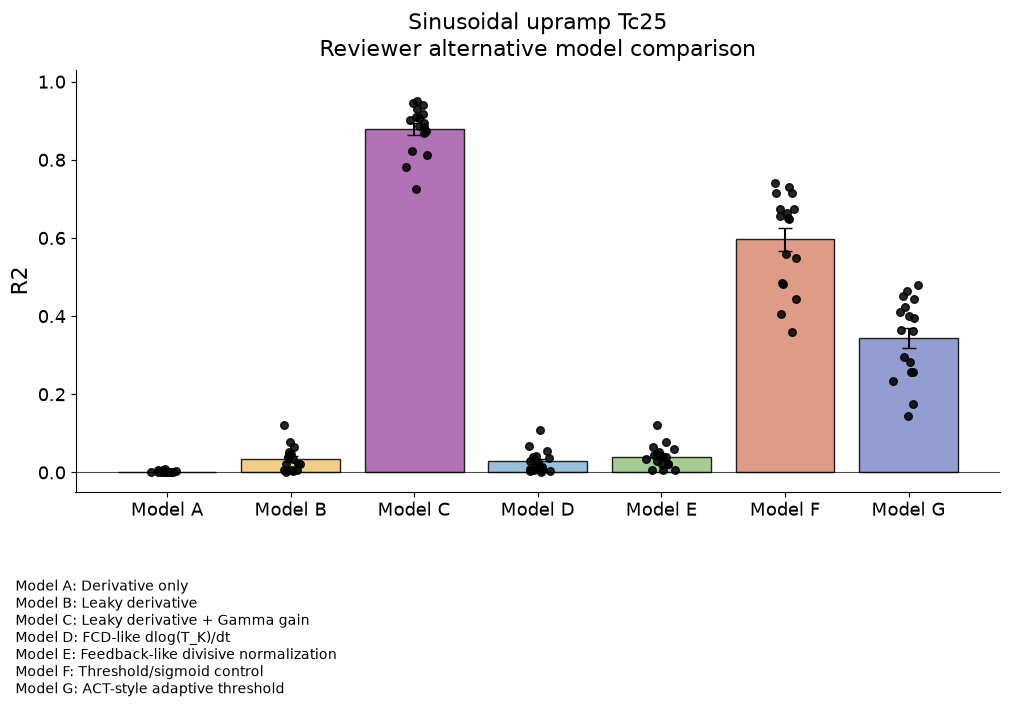


Interpretation note:
- Models A-C are the original paper models/baselines.
- Models D-G are alternative controls: FCD-like, feedback/adaptive normalization, threshold/sigmoid, and ACT-style adaptive threshold.
- Model G uses two biological parameters, tau_ACT and K_ACT; T_max is fixed from the shared stimulus.
- This section is not cross-validated; it is a direct per-worm goodness-of-fit comparison.
- Each worm still receives its own affine readout a,b, as in the original fitting pipeline.


In [35]:

# ============================================================
# REVIEWER 3: alternative model comparison, Models A-G
# No cross-validation here.
# This cell does not delete or change any earlier code.
# It fits each worm/replicate independently, then plots R² as
# bar + scatter for Models A-G.
#
# Model A: derivative only (original baseline)
# Model B: leaky derivative (original model)
# Model C: leaky derivative + Gamma gain (paper model)
# Model D: FCD-like relative derivative, dlog(T_K)/dt
# Model E: feedback-like divisive normalization
# Model F: threshold/sigmoid alternative
# Model G: ACT-style adaptive concentration threshold
#
# IMPORTANT: SAVE_ALT_MODEL_FIGURES is controlled by the global SAVE_FIGURES variable.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import wilcoxon
from scipy.special import expit

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------- USER CONTROLS ----------------
N_TRIALS_ALT_MODELS = 300        # Optuna optimization attempts, not experimental trials
SEED_BASE_ALT_MODELS = 11
DROP_INITIAL_SECONDS_ALT = 10.0
SHOW_OPTUNA_PROGRESS_ALT = False
PLOT_ALT_MODEL_RESULTS = True
SAVE_ALT_MODEL_FIGURES = SAVE_FIGURES   # controlled by global SAVE_FIGURES
# ------------------------------------------------

# Safety checks: this section uses variables/functions already created by earlier cells.
required_names_alt = [
    "Time_ramp", "Temp_ramp", "Ca_mat", "rep_cols",
    "fit_gain_offset", "r2_nan", "stable_seed", "set_all_seeds",
    "model_1_derivative_gain_only", "model_2_derivative_with_tauD",
    "model_3_full_minimal_gamma",
]
missing_alt = [name for name in required_names_alt if name not in globals()]
if missing_alt:
    raise RuntimeError(f"Run the earlier notebook cells first. Missing: {missing_alt}")

Time_alt = np.asarray(Time_ramp, dtype=float)
Temp_alt = np.asarray(Temp_ramp, dtype=float)
Ca_alt = np.asarray(Ca_mat, dtype=float)

mask_alt = Time_alt >= (float(Time_alt[0]) + float(DROP_INITIAL_SECONDS_ALT))
if np.sum(mask_alt) < 10:
    raise RuntimeError("Too few time points after DROP_INITIAL_SECONDS_ALT.")

T_MIN_ALT = float(np.nanmin(Temp_alt[mask_alt]))
T_MAX_ALT = float(np.nanmax(Temp_alt[mask_alt]))
T_RANGE_ALT = max(T_MAX_ALT - T_MIN_ALT, 1e-3)


def alt_one_pole_filter(time, signal, tau):
    """Simple one-pole low-pass filter used for reviewer alternative models."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    out = np.zeros_like(signal, dtype=float)
    tau = float(max(tau, 1e-6))
    default_dt = float(np.nanmedian(np.diff(time)))
    for i in range(1, len(signal)):
        dt = float(time[i] - time[i - 1])
        if (not np.isfinite(dt)) or dt <= 0:
            dt = default_dt
        alpha = 1.0 - np.exp(-dt / tau)
        out[i] = out[i - 1] + alpha * (signal[i] - out[i - 1])
    return out


def alt_derivative(time, signal):
    """NaN-safe numerical derivative."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    d = np.zeros_like(signal, dtype=float)
    dt = np.diff(time)
    finite_dt = np.isfinite(dt) & (dt != 0)
    fallback_dt = float(np.nanmedian(dt[finite_dt])) if np.any(finite_dt) else 1.0
    dt[~finite_dt] = fallback_dt
    d[1:] = np.diff(signal) / dt
    return d


def model_4_fcd_like_kelvin(Time, Temp, tauD):
    """
    Model D: Fold-change-detection-like control.
    Uses dlog(T_K)/dt, where T_K is absolute temperature in Kelvin.
    This captures relative/fractional temperature change rather than raw dT/dt.
    """
    T_kelvin = np.asarray(Temp, dtype=float) + 273.15
    dlogT = alt_derivative(Time, np.log(np.clip(T_kelvin, 1e-9, None)))
    return alt_one_pole_filter(Time, dlogT, tauD)


def model_5_feedback_divisive_normalization(Time, Temp, tauD, tauA, norm_k):
    """
    Model E: feedback/adaptive-scaling-like control.
    First creates a leaky derivative drive D, then compresses it by a slow
    activity/adaptation variable A. This asks whether generic adaptive
    compression can explain the data without a Gamma gain window.
    """
    dT = alt_derivative(Time, Temp)
    D = alt_one_pole_filter(Time, dT, tauD)
    A = alt_one_pole_filter(Time, np.abs(D), tauA)
    return D / (1.0 + float(norm_k) * np.maximum(A, 0.0))


def model_6_threshold_sigmoid(Time, Temp, tauD, T_thr, sigmoid_slope):
    """
    Model F: threshold/sigmoid control.
    A leaky derivative drive is multiplied by a smooth temperature-dependent
    threshold function. This tests whether a threshold-like response window,
    rather than a Gamma gain window, can explain the data.
    """
    dT = alt_derivative(Time, Temp)
    D = alt_one_pole_filter(Time, dT, tauD)
    W = expit(float(sigmoid_slope) * (np.asarray(Temp, dtype=float) - float(T_thr)))
    return D * W


def model_7_act_adaptive_threshold(Time, Temp, tau_ACT, K_ACT):
    """
    Model G: ACT-style adaptive concentration-threshold control.

    The original Levy & Bargmann ACT model detects decreases in a positive
    concentration signal. To preserve that direction for warming-sensitive AFD,
    temperature is converted to a non-negative 'coolness' signal:

        S(t) = T_max - T(t)

    so warming makes S(t) decrease.

    The adaptive threshold follows the ACT architecture:

        target(t) = K_ACT * (1 - exp(-S(t) / K_ACT))
        tau_ACT * dtheta/dt = target(t) - theta(t)
        C_G(t) = max(theta(t) - S(t), 0)

    T_max is fixed by the shared stimulus and is not fitted.

    Shared biological parameters:
        tau_ACT : adaptation timescale
        K_ACT   : threshold saturation scale

    Reference:
        Levy & Bargmann, Neuron (2020), DOI: 10.1016/j.neuron.2019.10.034
    """
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    tau_ACT = float(max(tau_ACT, 1e-6))
    K_ACT = float(max(K_ACT, 1e-9))

    # Fixed transformation of the shared temperature stimulus.
    S = np.maximum(T_MAX_ALT - Temp, 0.0)

    # ACT steady-state threshold target.
    target = K_ACT * (1.0 - np.exp(-S / K_ACT))

    # Dynamic adaptive threshold, initialized at steady state for the first input.
    theta = np.empty_like(target, dtype=float)
    theta[0] = target[0]

    dt_all = np.diff(Time)
    finite_dt = np.isfinite(dt_all) & (dt_all > 0)
    default_dt = float(np.nanmedian(dt_all[finite_dt])) if np.any(finite_dt) else 1.0

    for i in range(1, len(Time)):
        dt = float(Time[i] - Time[i - 1])
        if (not np.isfinite(dt)) or dt <= 0:
            dt = default_dt
        alpha = 1.0 - np.exp(-dt / tau_ACT)
        theta[i] = theta[i - 1] + alpha * (target[i] - theta[i - 1])

    return np.maximum(theta - S, 0.0)


alt_model_configs = [
    {"id": "deriv_gain",    "name": "Model A", "description": "Derivative only"},
    {"id": "deriv_tau",     "name": "Model B", "description": "Leaky derivative"},
    {"id": "full_gamma",    "name": "Model C", "description": "Leaky derivative + Gamma gain"},
    {"id": "fcd_like",      "name": "Model D", "description": "FCD-like dlog(T_K)/dt"},
    {"id": "feedback_norm", "name": "Model E", "description": "Feedback-like divisive normalization"},
    {"id": "threshold_sig", "name": "Model F", "description": "Threshold/sigmoid control"},
    {"id": "act_threshold", "name": "Model G", "description": "ACT-style adaptive threshold"},
]


def _suggest_alt_params(trial, model_id):
    """Parameter ranges for Models A-G."""
    if model_id == "deriv_gain":
        return {}

    if model_id == "deriv_tau":
        return {"tauD": trial.suggest_float("tauD", 40.0, 60.0, log=True)}

    if model_id == "full_gamma":
        # Same ranges as the original notebook's Model C.
        return {
            "tauD":    trial.suggest_float("tauD",    40.0, 60.0, log=True),
            "T_on":    trial.suggest_float("T_on",    20.0, 21.0),
            "k_shape": trial.suggest_float("k_shape", 1.5, 8.0),
            "k_scale": trial.suggest_float("k_scale", 0.2, 5.0),
        }

    if model_id == "fcd_like":
        return {"tauD": trial.suggest_float("tauD", 40.0, 60.0, log=True)}

    if model_id == "feedback_norm":
        return {
            "tauD":   trial.suggest_float("tauD",   40.0, 60.0, log=True),
            "tauA":   trial.suggest_float("tauA",   1.0, 300.0, log=True),
            "norm_k": trial.suggest_float("norm_k", 0.01, 200.0, log=True),
        }

    if model_id == "threshold_sig":
        return {
            "tauD":          trial.suggest_float("tauD", 40.0, 60.0, log=True),
            "T_thr":         trial.suggest_float("T_thr", T_MIN_ALT - 2.0, T_MAX_ALT + 2.0),
            "sigmoid_slope": trial.suggest_float("sigmoid_slope", 0.05, 25.0, log=True),
        }

    if model_id == "act_threshold":
        return {
            "tau_ACT": trial.suggest_float("tau_ACT", 40.0, 60.0, log=True),
            "K_ACT": trial.suggest_float(
                "K_ACT",
                max(0.01, 0.01 * T_RANGE_ALT),
                max(1.0, 10.0 * T_RANGE_ALT),
                log=True,
            ),
        }

    raise ValueError(f"Unknown model_id: {model_id}")


def _build_alt_model(model_id, params):
    """Build latent model trace for Models A-G."""
    if model_id == "deriv_gain":
        return model_1_derivative_gain_only(Time_alt, Temp_alt)

    if model_id == "deriv_tau":
        return model_2_derivative_with_tauD(Time_alt, Temp_alt, tauD=float(params["tauD"]))

    if model_id == "full_gamma":
        return model_3_full_minimal_gamma(
            Time_alt, Temp_alt,
            tauD=float(params["tauD"]),
            T_on=float(params["T_on"]),
            k_shape=float(params["k_shape"]),
            k_scale=float(params["k_scale"]),
        )

    if model_id == "fcd_like":
        return model_4_fcd_like_kelvin(Time_alt, Temp_alt, tauD=float(params["tauD"]))

    if model_id == "feedback_norm":
        return model_5_feedback_divisive_normalization(
            Time_alt, Temp_alt,
            tauD=float(params["tauD"]),
            tauA=float(params["tauA"]),
            norm_k=float(params["norm_k"]),
        )

    if model_id == "threshold_sig":
        return model_6_threshold_sigmoid(
            Time_alt, Temp_alt,
            tauD=float(params["tauD"]),
            T_thr=float(params["T_thr"]),
            sigmoid_slope=float(params["sigmoid_slope"]),
        )

    if model_id == "act_threshold":
        return model_7_act_adaptive_threshold(
            Time_alt, Temp_alt,
            tau_ACT=float(params["tau_ACT"]),
            K_ACT=float(params["K_ACT"]),
        )

    raise ValueError(f"Unknown model_id: {model_id}")


def _score_alt_model_on_one_worm(model_id, params, Calcium):
    """Fit a,b for one worm and return R² and fitted trace."""
    C_model = _build_alt_model(model_id, params)
    if (not np.all(np.isfinite(C_model))) or (np.nanstd(C_model[mask_alt]) < 1e-12):
        return np.nan, np.nan, np.nan, np.full_like(Time_alt, np.nan, dtype=float)

    a, b = fit_gain_offset(C_model[mask_alt], Calcium[mask_alt])
    if (not np.isfinite(a)) or (not np.isfinite(b)):
        return np.nan, np.nan, np.nan, np.full_like(Time_alt, np.nan, dtype=float)

    fit = a * C_model + b
    R2 = r2_nan(Calcium[mask_alt], fit[mask_alt])
    return float(R2), float(a), float(b), fit


class ReviewerAltObjective:
    """Per-worm objective for Models A-G."""
    def __init__(self, model_id, Calcium):
        self.model_id = model_id
        self.Calcium = np.asarray(Calcium, dtype=float)

    def __call__(self, trial):
        params = _suggest_alt_params(trial, self.model_id)
        R2, _, _, _ = _score_alt_model_on_one_worm(self.model_id, params, self.Calcium)
        if not np.isfinite(R2):
            return -1e9
        return float(R2)


# ============================================================
# Fit Models A-G independently for each worm/replicate
# ============================================================

alt_r2_by_model = {cfg["id"]: [] for cfg in alt_model_configs}
alt_rows = []
alt_param_rows = []

print("\n" + "=" * 80)
print(f"REVIEWER 3 ALTERNATIVE MODEL COMPARISON — Models A-G — {dataset}")
print("No cross-validation in this section; each worm/replicate is fit independently.")
print("Figures are not saved; SAVE_ALT_MODEL_FIGURES = False.")
print("=" * 80)

for rep_idx in range(Ca_alt.shape[1]):
    Calcium = np.asarray(Ca_alt[:, rep_idx], dtype=float)
    rep_name = str(rep_cols[rep_idx])

    if np.isfinite(Calcium).sum() < 10:
        print(f"Replicate {rep_name} skipped: too few finite points")
        for cfg in alt_model_configs:
            alt_r2_by_model[cfg["id"]].append(np.nan)
            alt_rows.append({
                "rep_idx": int(rep_idx), "rep_name": rep_name,
                "model_id": cfg["id"], "model_name": cfg["name"],
                "description": cfg["description"], "R2": np.nan,
                "a": np.nan, "b": np.nan,
            })
        continue

    print(f"\nReplicate {rep_idx + 1}/{Ca_alt.shape[1]}: {rep_name}")

    for cfg in alt_model_configs:
        model_id = cfg["id"]
        model_name = cfg["name"]

        if model_id == "deriv_gain":
            best_params = {}
        else:
            seed_val = stable_seed(dataset, rep_name, model_id, base=SEED_BASE_ALT_MODELS)
            set_all_seeds(seed_val)
            sampler = optuna.samplers.TPESampler(seed=seed_val)
            study = optuna.create_study(direction="maximize", sampler=sampler)
            study.optimize(
                ReviewerAltObjective(model_id, Calcium),
                n_trials=N_TRIALS_ALT_MODELS,
                show_progress_bar=SHOW_OPTUNA_PROGRESS_ALT,
                n_jobs=1,
            )
            best_params = dict(study.best_params)

        R2, a, b, fit = _score_alt_model_on_one_worm(model_id, best_params, Calcium)
        alt_r2_by_model[model_id].append(R2)

        row = {
            "rep_idx": int(rep_idx),
            "rep_name": rep_name,
            "model_id": model_id,
            "model_name": model_name,
            "description": cfg["description"],
            "R2": R2,
            "a": a,
            "b": b,
        }
        for k, v in best_params.items():
            row[k] = float(v)
        alt_rows.append(row)

        param_row = {
            "rep_idx": int(rep_idx),
            "rep_name": rep_name,
            "model_id": model_id,
            "model_name": model_name,
            "description": cfg["description"],
        }
        for k, v in best_params.items():
            param_row[k] = float(v)
        alt_param_rows.append(param_row)

        print(f"  {model_name} ({cfg['description']}): R2 = {R2:.4f}")

alt_fit_df = pd.DataFrame(alt_rows)
alt_param_df = pd.DataFrame(alt_param_rows)

# Summary table
summary_rows = []
for cfg in alt_model_configs:
    vals = np.asarray(alt_r2_by_model[cfg["id"]], dtype=float)
    finite = vals[np.isfinite(vals)]
    summary_rows.append({
        "model_id": cfg["id"],
        "model_name": cfg["name"],
        "description": cfg["description"],
        "n": int(finite.size),
        "mean_R2": float(np.nanmean(finite)) if finite.size else np.nan,
        "median_R2": float(np.nanmedian(finite)) if finite.size else np.nan,
        "std_R2": float(np.nanstd(finite, ddof=1)) if finite.size > 1 else np.nan,
        "sem_R2": float(np.nanstd(finite, ddof=1) / np.sqrt(finite.size)) if finite.size > 1 else np.nan,
    })

alt_summary_df = pd.DataFrame(summary_rows)
print("\nSummary: Models A-G")
display(alt_summary_df)

# Paired comparisons against Model C
paired_rows = []
modelC_df = alt_fit_df[alt_fit_df["model_id"] == "full_gamma"][["rep_idx", "R2"]].rename(columns={"R2": "R2_Model_C"})
for cfg in alt_model_configs:
    if cfg["id"] == "full_gamma":
        continue
    other_df = alt_fit_df[alt_fit_df["model_id"] == cfg["id"]][["rep_idx", "R2"]].rename(columns={"R2": "R2_other"})
    merged = pd.merge(modelC_df, other_df, on="rep_idx", how="inner")
    merged = merged[np.isfinite(merged["R2_Model_C"]) & np.isfinite(merged["R2_other"])]
    delta = merged["R2_Model_C"].to_numpy() - merged["R2_other"].to_numpy()
    if len(delta) >= 2 and np.any(np.abs(delta) > 0):
        try:
            pval = float(wilcoxon(delta).pvalue)
        except Exception:
            pval = np.nan
    else:
        pval = np.nan
    paired_rows.append({
        "comparison": f"Model C - {cfg['name']}",
        "other_model_description": cfg["description"],
        "n_paired_worms": int(len(delta)),
        "mean_delta_R2": float(np.nanmean(delta)) if len(delta) else np.nan,
        "median_delta_R2": float(np.nanmedian(delta)) if len(delta) else np.nan,
        "wilcoxon_p": pval,
    })

alt_paired_df = pd.DataFrame(paired_rows)
print("\nPaired comparisons against Model C:")
display(alt_paired_df)

# ============================================================
# Plot: bar + individual worm scatter, Models A-G
# ============================================================
if PLOT_ALT_MODEL_RESULTS:
    model_ids = [cfg["id"] for cfg in alt_model_configs]
    model_names = [cfg["name"] for cfg in alt_model_configs]
    descriptions = [cfg["description"] for cfg in alt_model_configs]
    r2_arrays = [np.asarray(alt_r2_by_model[mid], dtype=float) for mid in model_ids]
    means = np.array([np.nanmean(x) for x in r2_arrays])
    sems = np.array([
        np.nanstd(x[np.isfinite(x)], ddof=1) / np.sqrt(np.isfinite(x).sum())
        if np.isfinite(x).sum() > 1 else 0.0
        for x in r2_arrays
    ])

    x = np.arange(len(model_ids))
    bar_colors = ["#b8b8b8", "#f0c571", "#a559aa", "#86b6d8", "#95c47f", "#d98b72", "#7f8cc9"]

    fig, ax = plt.subplots(figsize=(10.2, 5.4))
    ax.bar(
        x, means, yerr=sems, capsize=5,
        color=bar_colors[:len(x)], edgecolor="black",
        linewidth=1.0, alpha=0.85, ecolor="black", zorder=2,
    )

    rng = np.random.default_rng(0)
    for i, arr in enumerate(r2_arrays):
        vals = arr[np.isfinite(arr)]
        jitter = rng.normal(0.0, 0.055, size=vals.size)
        ax.scatter(
            np.full(vals.size, x[i]) + jitter,
            vals,
            color="black", s=30, alpha=0.85,
            zorder=3,
        )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=13)
    ax.set_ylabel("R2", fontsize=16)
    ax.set_title(f"{dataset}\nReviewer alternative model comparison", fontsize=16, pad=10)
    ax.tick_params(axis="y", labelsize=13)

    finite_all = np.concatenate([arr[np.isfinite(arr)] for arr in r2_arrays if np.isfinite(arr).any()])
    if finite_all.size:
        ymin = min(0.0, float(np.nanmin(finite_all)) - 0.05)
        ymax = max(1.0, float(np.nanmax(finite_all)) + 0.08)
        ax.set_ylim(ymin, ymax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add model descriptions below as a text note for readability.
    desc_text = "\n".join([f"{name}: {desc}" for name, desc in zip(model_names, descriptions)])
    fig.text(0.02, -0.08, desc_text, ha="left", va="top", fontsize=10)
    fig.tight_layout()

    # Save figure as SVG before showing
    if SAVE_ALT_MODEL_FIGURES:
        import os
        import re
        if "FIGURE_OUTPUT_DIR" not in globals():
            FIGURE_OUTPUT_DIR = "."
        os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)
        safe_dataset = re.sub(r"[^A-Za-z0-9_-]+", "_", str(dataset)).strip("_")
        svg_filename = f"{safe_dataset}_Reviewer3_ALT_Models_A_G.svg"
        svg_path = os.path.join(FIGURE_OUTPUT_DIR, svg_filename)
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"Saved SVG figure as: {svg_path}")

    plt.show()

print("\nInterpretation note:")
print("- Models A-C are the original paper models/baselines.")
print("- Models D-G are alternative controls: FCD-like, feedback/adaptive normalization, threshold/sigmoid, and ACT-style adaptive threshold.")
print("- Model G uses two biological parameters, tau_ACT and K_ACT; T_max is fixed from the shared stimulus.")
print("- This section is not cross-validated; it is a direct per-worm goodness-of-fit comparison.")
print("- Each worm still receives its own affine readout a,b, as in the original fitting pipeline.")


# Reviewer 3 alternative model comparison with cross-validation: Models A–G

This section adds the same Model A–G comparison as above, but now uses worm-level cross-validation.

For each cross-validation split:

1. A subset of worms is used as the training set.
2. Biological model parameters are optimized only on the training worms.
3. Those biological parameters are frozen.
4. The frozen model is evaluated on held-out worms.
5. For each held-out worm, only the nuisance affine readout parameters `a` and `b` are fit, because these account for fluorescence scale and baseline differences and cannot change the temporal shape of the model prediction.

Model G is the same ACT-style adaptive threshold model used in the non-cross-validated comparison. Its shared biological parameters (`tau_ACT`, `K_ACT`) are trained only on the training worms and then frozen for held-out worms.

The plot shows held-out R² for Models A–G. Statistical labels are paired Wilcoxon signed-rank tests comparing each model against Model C across held-out worms.



REVIEWER 3 CROSS-VALIDATED ALTERNATIVE MODEL COMPARISON — Models A-G — Sinusoidal upramp Tc25
Mode: kfold; folds/splits: 5; worms: 17
Biological parameters are fit only on training worms and then frozen.
Only a,b are fit per held-out worm as fluorescence scale/offset nuisance terms.
Figure saving is ON; output folder: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp

Fold 1/5: train n=13, test n=4
  Model A: train mean R2=0.0018; test mean R2=0.0020
  Model B: train mean R2=0.0418; test mean R2=0.0437
  Model C: train mean R2=0.8275; test mean R2=0.8144
  Model D: train mean R2=0.0357; test mean R2=0.0380
  Model E: train mean R2=0.0418; test mean R2=0.0437
  Model F: train mean R2=0.5673; test mean R2=0.5799
  Model G: train mean R2=0.3421; test mean R2=0.3345

Fold 2/5: train n=13, test n=4
  Model A: train mean R2=0.0023; test mean R2=0.0004
  Model B: train mean R2=0.0444; test mean R2=0.0351
  Model C: train mean R2=0.8200; test mean R

,model_id,model_name,description,n,mean_R2,median_R2,std_R2,sem_R2
0,deriv_gain,Model A,Derivative only,17,0.001840,0.000738,0.002625,0.000637
1,deriv_tau,Model B,Leaky derivative,17,0.042242,0.030060,0.036268,0.008796
2,full_gamma,Model C,Leaky derivative + Gamma gain,17,0.815909,0.829371,0.093112,0.022583
3,fcd_like,Model D,FCD-like dlog(T_K)/dt,17,0.036263,0.024663,0.032614,0.007910
4,feedback_norm,Model E,Feedback-like divisive normalization,17,0.042235,0.030062,0.036263,0.008795
5,threshold_sig,Model F,Threshold/sigmoid control,17,0.566318,0.597139,0.124195,0.030122
6,act_threshold,Model G,ACT-style adaptive threshold,17,0.339995,0.364549,0.105266,0.025531



Best-fit shared biological parameters per fold:


,fold,model_id,model_name,description,train_n,test_n,train_mean_R2_objective,test_mean_R2,tauD,T_on,k_shape,k_scale,tauA,norm_k,T_thr,sigmoid_slope,tau_ACT,K_ACT
0,1,deriv_gain,Model A,Derivative only,13,4,0.001785,0.002019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,deriv_tau,Model B,Leaky derivative,13,4,0.041784,0.043732,99.996152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,full_gamma,Model C,Leaky derivative + Gamma gain,13,4,0.827514,0.814363,47.975489,20.016010,1.918871,1.724197,NaN,NaN,NaN,NaN,NaN,NaN
3,1,fcd_like,Model D,FCD-like dlog(T_K)/dt,13,4,0.035741,0.037964,99.987327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,feedback_norm,Model E,Feedback-like divisive normalization,13,4,0.041772,0.043722,99.986538,NaN,NaN,NaN,1.537230,0.061613,NaN,NaN,NaN,NaN
5,1,threshold_sig,Model F,Threshold/sigmoid control,13,4,0.567269,0.579888,50.592243,NaN,NaN,NaN,NaN,NaN,20.192542,13.514547,NaN,NaN
6,1,act_threshold,Model G,ACT-style adaptive threshold,13,4,0.342052,0.334477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.995221,124.809996
7,2,deriv_gain,Model A,Derivative only,13,4,0.002274,0.000431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2,deriv_tau,Model B,Leaky derivative,13,4,0.044433,0.035109,99.983476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2,full_gamma,Model C,Leaky derivative + Gamma gain,13,4,0.820005,0.840343,50.699396,20.017435,1.741117,2.034241,NaN,NaN,NaN,NaN,NaN,NaN



Paired held-out comparisons against Model C using Wilcoxon signed-rank test:


,comparison,other_model_description,n_paired_worms,mean_delta_R2,median_delta_R2,wilcoxon_p,label
0,Model C - Model A,Derivative only,17,0.814069,0.829261,0.000015,***
1,Model C - Model B,Leaky derivative,17,0.773667,0.779423,0.000015,***
2,Model C - Model D,FCD-like dlog(T_K)/dt,17,0.779646,0.782622,0.000015,***
3,Model C - Model E,Feedback-like divisive normalization,17,0.773674,0.779420,0.000015,***
4,Model C - Model F,Threshold/sigmoid control,17,0.249591,0.247547,0.000015,***
5,Model C - Model G,ACT-style adaptive threshold,17,0.475914,0.487979,0.000015,***


Saved SVG figure as: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/Sinusoidal_upramp_Tc25_Reviewer3_CV_Models_A_G.svg


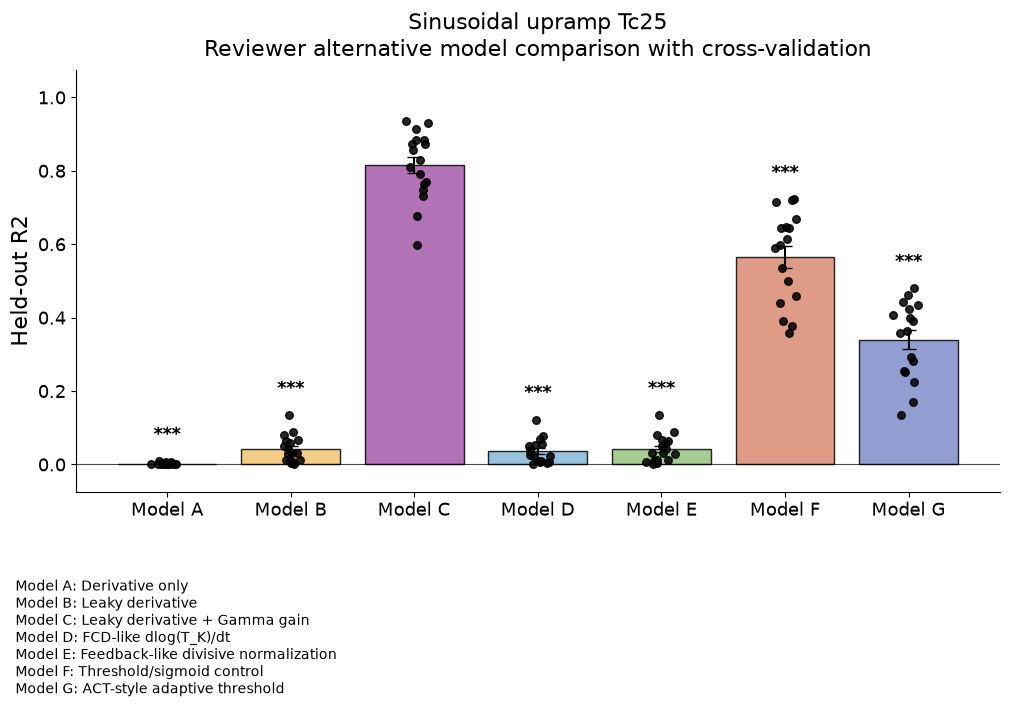


Interpretation note:
- This is the cross-validated version of the Model A-G comparison.
- Biological model parameters are trained on a subset of worms and frozen for held-out worms.
- Per-worm a,b are fit only as nuisance fluorescence scale/offset parameters.
- Model G shares tau_ACT and K_ACT across training worms; those parameters are frozen for held-out worms.
- Statistical labels compare each model to Model C using a paired Wilcoxon signed-rank test.
- Label convention: ** p<0.01, * p<0.05, n.s. p>0.05, *** p<0.001.


In [36]:
# ============================================================
# REVIEWER 3: cross-validated alternative model comparison
# Models A-G, train worms -> held-out worms
#
# This cell is added at the bottom and does not modify earlier code.
# It saves the final figure as SVG if ALT_CV_SAVE_FIGURES = True.
#
# Model A: derivative only
# Model B: leaky derivative
# Model C: leaky derivative + Gamma gain
# Model D: FCD-like relative derivative, dlog(T_K)/dt
# Model E: feedback-like divisive normalization
# Model F: threshold/sigmoid control
# Model G: ACT-style adaptive concentration threshold
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import wilcoxon
from scipy.special import expit

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------- USER CONTROLS ----------------
ALT_CV_MODE = "kfold"                 # "kfold" or "loo"
ALT_CV_N_SPLITS = 5                    # used only if ALT_CV_MODE = "kfold"
ALT_CV_N_OPTUNA_TRIALS = 300           # optimization attempts, not experimental trials/worms
ALT_CV_RANDOM_SEED = 1
ALT_CV_DROP_INITIAL_SECONDS = 10.0
ALT_CV_SHOW_OPTUNA_PROGRESS = False
ALT_CV_PLOT_RESULTS = True
ALT_CV_SAVE_FIGURES = SAVE_FIGURES      # controlled by global SAVE_FIGURES
ALT_CV_OUTPUT_DIR = FIGURE_OUTPUT_DIR
# ------------------------------------------------

# Safety checks
required_names_alt_cv = [
    "Time_ramp", "Temp_ramp", "Ca_mat", "rep_cols",
    "fit_gain_offset", "r2_nan",
    "model_1_derivative_gain_only", "model_2_derivative_with_tauD",
    "model_3_full_minimal_gamma",
]
missing_alt_cv = [name for name in required_names_alt_cv if name not in globals()]
if missing_alt_cv:
    raise RuntimeError(f"Run the earlier notebook cells first. Missing: {missing_alt_cv}")

if "dataset" not in globals():
    dataset = "Tc25 dataset"

Time_alt_cv = np.asarray(Time_ramp, dtype=float)
Temp_alt_cv = np.asarray(Temp_ramp, dtype=float)
Ca_alt_cv = np.asarray(Ca_mat, dtype=float)

mask_alt_cv = Time_alt_cv >= (float(Time_alt_cv[0]) + float(ALT_CV_DROP_INITIAL_SECONDS))
if np.sum(mask_alt_cv) < 10:
    raise RuntimeError("Too few time points after ALT_CV_DROP_INITIAL_SECONDS.")

T_MIN_ALT_CV = float(np.nanmin(Temp_alt_cv[mask_alt_cv]))
T_MAX_ALT_CV = float(np.nanmax(Temp_alt_cv[mask_alt_cv]))
T_RANGE_ALT_CV = max(T_MAX_ALT_CV - T_MIN_ALT_CV, 1e-3)

# ---------- helper functions for reviewer alternative models ----------
def alt_cv_one_pole_filter(time, signal, tau):
    """Simple one-pole low-pass filter used for reviewer alternative models."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    out = np.zeros_like(signal, dtype=float)
    tau = float(max(tau, 1e-6))
    dt_all = np.diff(time)
    finite_dt = np.isfinite(dt_all) & (dt_all > 0)
    default_dt = float(np.nanmedian(dt_all[finite_dt])) if np.any(finite_dt) else 1.0
    for i in range(1, len(signal)):
        dt = float(time[i] - time[i - 1])
        if (not np.isfinite(dt)) or dt <= 0:
            dt = default_dt
        alpha = 1.0 - np.exp(-dt / tau)
        out[i] = out[i - 1] + alpha * (signal[i] - out[i - 1])
    return out


def alt_cv_derivative(time, signal):
    """NaN-safe numerical derivative."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    d = np.zeros_like(signal, dtype=float)
    dt = np.diff(time)
    finite_dt = np.isfinite(dt) & (dt != 0)
    fallback_dt = float(np.nanmedian(dt[finite_dt])) if np.any(finite_dt) else 1.0
    dt = dt.copy()
    dt[~finite_dt] = fallback_dt
    d[1:] = np.diff(signal) / dt
    return d


def alt_cv_model_4_fcd_like_kelvin(Time, Temp, tauD):
    """
    Model D: Fold-change-detection-like control.
    Uses dlog(T_K)/dt, where T_K is absolute temperature in Kelvin.
    """
    T_kelvin = np.asarray(Temp, dtype=float) + 273.15
    dlogT = alt_cv_derivative(Time, np.log(np.clip(T_kelvin, 1e-9, None)))
    return alt_cv_one_pole_filter(Time, dlogT, tauD)


def alt_cv_model_5_feedback_divisive_normalization(Time, Temp, tauD, tauA, norm_k):
    """
    Model E: feedback/adaptive-scaling-like control.
    A leaky derivative drive is compressed by a slower adaptation variable.
    """
    dT = alt_cv_derivative(Time, Temp)
    D = alt_cv_one_pole_filter(Time, dT, tauD)
    A = alt_cv_one_pole_filter(Time, np.abs(D), tauA)
    return D / (1.0 + float(norm_k) * np.maximum(A, 0.0))


def alt_cv_model_6_threshold_sigmoid(Time, Temp, tauD, T_thr, sigmoid_slope):
    """
    Model F: threshold/sigmoid control.
    A leaky derivative drive is multiplied by a smooth temperature threshold.
    """
    dT = alt_cv_derivative(Time, Temp)
    D = alt_cv_one_pole_filter(Time, dT, tauD)
    W = expit(float(sigmoid_slope) * (np.asarray(Temp, dtype=float) - float(T_thr)))
    return D * W


def alt_cv_model_7_act_adaptive_threshold(Time, Temp, tau_ACT, K_ACT):
    """
    Model G: ACT-style adaptive concentration-threshold control.

    The original Levy & Bargmann ACT model detects decreases in a positive
    concentration signal. For warming-sensitive AFD we use:

        S(t) = T_max - T(t)

    so warming makes S(t) decrease, preserving the original ACT crossing
    direction.

        target(t) = K_ACT * (1 - exp(-S(t) / K_ACT))
        tau_ACT * dtheta/dt = target(t) - theta(t)
        C_G(t) = max(theta(t) - S(t), 0)

    T_max is fixed from the shared stimulus and is not fitted.
    """
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    tau_ACT = float(max(tau_ACT, 1e-6))
    K_ACT = float(max(K_ACT, 1e-9))

    S = np.maximum(T_MAX_ALT_CV - Temp, 0.0)
    target = K_ACT * (1.0 - np.exp(-S / K_ACT))

    theta = np.empty_like(target, dtype=float)
    theta[0] = target[0]

    dt_all = np.diff(Time)
    finite_dt = np.isfinite(dt_all) & (dt_all > 0)
    default_dt = float(np.nanmedian(dt_all[finite_dt])) if np.any(finite_dt) else 1.0

    for i in range(1, len(Time)):
        dt = float(Time[i] - Time[i - 1])
        if (not np.isfinite(dt)) or dt <= 0:
            dt = default_dt
        alpha = 1.0 - np.exp(-dt / tau_ACT)
        theta[i] = theta[i - 1] + alpha * (target[i] - theta[i - 1])

    return np.maximum(theta - S, 0.0)


alt_cv_model_configs = [
    {"id": "deriv_gain",    "name": "Model A", "description": "Derivative only"},
    {"id": "deriv_tau",     "name": "Model B", "description": "Leaky derivative"},
    {"id": "full_gamma",    "name": "Model C", "description": "Leaky derivative + Gamma gain"},
    {"id": "fcd_like",      "name": "Model D", "description": "FCD-like dlog(T_K)/dt"},
    {"id": "feedback_norm", "name": "Model E", "description": "Feedback-like divisive normalization"},
    {"id": "threshold_sig", "name": "Model F", "description": "Threshold/sigmoid control"},
    {"id": "act_threshold", "name": "Model G", "description": "ACT-style adaptive threshold"},
]


def alt_cv_suggest_params(trial, model_id):
    """Parameter ranges for Models A-G."""
    if model_id == "deriv_gain":
        return {}

    if model_id == "deriv_tau":
        return {"tauD": trial.suggest_float("tauD", 0.5, 100.0, log=True)}

    if model_id == "full_gamma":
        # Same conceptual parameter set as the paper's Model C.
        return {
            "tauD":    trial.suggest_float("tauD",    40.0, 60.0, log=True),
            "T_on":    trial.suggest_float("T_on",    20.0, 21.0),
            "k_shape": trial.suggest_float("k_shape", 1.5, 8.0),
            "k_scale": trial.suggest_float("k_scale", 0.2, 5.0),
        }

    if model_id == "fcd_like":
        return {"tauD": trial.suggest_float("tauD", 0.5, 100.0, log=True)}

    if model_id == "feedback_norm":
        return {
            "tauD":   trial.suggest_float("tauD",   0.5, 100.0, log=True),
            "tauA":   trial.suggest_float("tauA",   1.0, 300.0, log=True),
            "norm_k": trial.suggest_float("norm_k", 0.01, 200.0, log=True),
        }

    if model_id == "threshold_sig":
        return {
            "tauD":          trial.suggest_float("tauD", 0.5, 100.0, log=True),
            "T_thr":         trial.suggest_float("T_thr", T_MIN_ALT_CV - 2.0, T_MAX_ALT_CV + 2.0),
            "sigmoid_slope": trial.suggest_float("sigmoid_slope", 0.05, 25.0, log=True),
        }

    if model_id == "act_threshold":
        return {
            "tau_ACT": trial.suggest_float("tau_ACT", 0.5, 300.0, log=True),
            "K_ACT": trial.suggest_float(
                "K_ACT",
                max(0.01, 0.01 * T_RANGE_ALT_CV),
                max(1.0, 10.0 * T_RANGE_ALT_CV),
                log=True,
            ),
        }

    raise ValueError(f"Unknown model_id: {model_id}")


def alt_cv_build_model(model_id, params):
    """Build latent model trace for Models A-G using frozen biological parameters."""
    if model_id == "deriv_gain":
        return model_1_derivative_gain_only(Time_alt_cv, Temp_alt_cv)

    if model_id == "deriv_tau":
        return model_2_derivative_with_tauD(Time_alt_cv, Temp_alt_cv, tauD=float(params["tauD"]))

    if model_id == "full_gamma":
        return model_3_full_minimal_gamma(
            Time_alt_cv, Temp_alt_cv,
            tauD=float(params["tauD"]),
            T_on=float(params["T_on"]),
            k_shape=float(params["k_shape"]),
            k_scale=float(params["k_scale"]),
        )

    if model_id == "fcd_like":
        return alt_cv_model_4_fcd_like_kelvin(Time_alt_cv, Temp_alt_cv, tauD=float(params["tauD"]))

    if model_id == "feedback_norm":
        return alt_cv_model_5_feedback_divisive_normalization(
            Time_alt_cv, Temp_alt_cv,
            tauD=float(params["tauD"]),
            tauA=float(params["tauA"]),
            norm_k=float(params["norm_k"]),
        )

    if model_id == "threshold_sig":
        return alt_cv_model_6_threshold_sigmoid(
            Time_alt_cv, Temp_alt_cv,
            tauD=float(params["tauD"]),
            T_thr=float(params["T_thr"]),
            sigmoid_slope=float(params["sigmoid_slope"]),
        )

    if model_id == "act_threshold":
        return alt_cv_model_7_act_adaptive_threshold(
            Time_alt_cv, Temp_alt_cv,
            tau_ACT=float(params["tau_ACT"]),
            K_ACT=float(params["K_ACT"]),
        )

    raise ValueError(f"Unknown model_id: {model_id}")


def alt_cv_score_model_on_worm(model_id, params, Calcium):
    """
    Score one worm using frozen biological parameters.
    Only a,b are fit for that worm as nuisance fluorescence readout terms.
    """
    C_model = alt_cv_build_model(model_id, params)
    if (not np.all(np.isfinite(C_model))) or (np.nanstd(C_model[mask_alt_cv]) < 1e-12):
        return np.nan, np.nan, np.nan

    a, b = fit_gain_offset(C_model[mask_alt_cv], Calcium[mask_alt_cv])
    if (not np.isfinite(a)) or (not np.isfinite(b)):
        return np.nan, np.nan, np.nan

    pred = a * C_model + b
    R2 = r2_nan(Calcium[mask_alt_cv], pred[mask_alt_cv])
    return float(R2), float(a), float(b)


def alt_cv_mean_R2_on_worm_indices(model_id, params, worm_indices):
    """Mean R² across a set of worms, fitting only a,b per worm."""
    r2_vals = []
    for idx in worm_indices:
        Calcium = np.asarray(Ca_alt_cv[:, idx], dtype=float)
        if np.isfinite(Calcium).sum() < 10:
            continue
        R2, _, _ = alt_cv_score_model_on_worm(model_id, params, Calcium)
        if np.isfinite(R2):
            r2_vals.append(R2)
    if len(r2_vals) == 0:
        return -1e9
    return float(np.mean(r2_vals))


class AltCVTrainingObjective:
    """Training objective: optimize biological parameters on training worms only."""
    def __init__(self, model_id, train_indices):
        self.model_id = model_id
        self.train_indices = np.asarray(train_indices, dtype=int)

    def __call__(self, trial):
        params = alt_cv_suggest_params(trial, self.model_id)
        score = alt_cv_mean_R2_on_worm_indices(self.model_id, params, self.train_indices)
        if not np.isfinite(score):
            return -1e9
        return float(score)


def alt_cv_make_splits(n_worms):
    """Create worm-level k-fold or leave-one-out splits."""
    indices = np.arange(n_worms)
    if ALT_CV_MODE.lower() == "loo":
        return [(np.setdiff1d(indices, [i]), np.array([i], dtype=int)) for i in indices]

    if ALT_CV_MODE.lower() == "kfold":
        n_splits = int(min(ALT_CV_N_SPLITS, n_worms))
        if n_splits < 2:
            raise ValueError("Need at least 2 worms/folds for k-fold cross-validation.")
        rng = np.random.default_rng(ALT_CV_RANDOM_SEED)
        shuffled = indices.copy()
        rng.shuffle(shuffled)
        fold_arrays = np.array_split(shuffled, n_splits)
        splits = []
        for test_idx in fold_arrays:
            test_idx = np.asarray(test_idx, dtype=int)
            train_idx = np.setdiff1d(indices, test_idx)
            splits.append((train_idx, test_idx))
        return splits

    raise ValueError('ALT_CV_MODE must be "kfold" or "loo"')


def alt_cv_sig_label(p):
    """Significance labels for paired comparisons against Model C."""
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


# ============================================================
# Run cross-validation for Models A-G
# ============================================================

n_worms_alt_cv = Ca_alt_cv.shape[1]
splits_alt_cv = alt_cv_make_splits(n_worms_alt_cv)

alt_cv_rows = []
alt_cv_param_rows = []

print("\n" + "=" * 80)
print(f"REVIEWER 3 CROSS-VALIDATED ALTERNATIVE MODEL COMPARISON — Models A-G — {dataset}")
print(f"Mode: {ALT_CV_MODE}; folds/splits: {len(splits_alt_cv)}; worms: {n_worms_alt_cv}")
print("Biological parameters are fit only on training worms and then frozen.")
print("Only a,b are fit per held-out worm as fluorescence scale/offset nuisance terms.")
print(f"Figure saving is {'ON' if ALT_CV_SAVE_FIGURES else 'OFF'}; output folder: {ALT_CV_OUTPUT_DIR}")
print("=" * 80)

for fold_i, (train_idx, test_idx) in enumerate(splits_alt_cv, start=1):
    print(f"\nFold {fold_i}/{len(splits_alt_cv)}: train n={len(train_idx)}, test n={len(test_idx)}")

    for cfg in alt_cv_model_configs:
        model_id = cfg["id"]
        model_name = cfg["name"]

        if model_id == "deriv_gain":
            best_params = {}
            train_score = alt_cv_mean_R2_on_worm_indices(model_id, best_params, train_idx)
        else:
            seed_val = stable_seed(dataset, "alt_cv", fold_i, model_id, base=ALT_CV_RANDOM_SEED)
            set_all_seeds(seed_val)
            sampler = optuna.samplers.TPESampler(seed=seed_val)
            study = optuna.create_study(direction="maximize", sampler=sampler)
            study.optimize(
                AltCVTrainingObjective(model_id, train_idx),
                n_trials=ALT_CV_N_OPTUNA_TRIALS,
                show_progress_bar=ALT_CV_SHOW_OPTUNA_PROGRESS,
                n_jobs=1,
            )
            best_params = dict(study.best_params)
            train_score = float(study.best_value)

        test_scores = []
        for idx in test_idx:
            Calcium = np.asarray(Ca_alt_cv[:, idx], dtype=float)
            R2, a, b = alt_cv_score_model_on_worm(model_id, best_params, Calcium)
            test_scores.append(R2)
            alt_cv_rows.append({
                "fold": int(fold_i),
                "rep_idx": int(idx),
                "rep_name": str(rep_cols[idx]),
                "model_id": model_id,
                "model_name": model_name,
                "description": cfg["description"],
                "R2": R2,
                "a": a,
                "b": b,
            })

        param_row = {
            "fold": int(fold_i),
            "model_id": model_id,
            "model_name": model_name,
            "description": cfg["description"],
            "train_n": int(len(train_idx)),
            "test_n": int(len(test_idx)),
            "train_mean_R2_objective": float(train_score),
            "test_mean_R2": float(np.nanmean(test_scores)),
        }
        for k, v in best_params.items():
            param_row[k] = float(v)
        alt_cv_param_rows.append(param_row)

        print(f"  {model_name}: train mean R2={train_score:.4f}; test mean R2={np.nanmean(test_scores):.4f}")

alt_cv_fit_df = pd.DataFrame(alt_cv_rows)
alt_cv_param_df = pd.DataFrame(alt_cv_param_rows)

# Summary table
alt_cv_summary_rows = []
for cfg in alt_cv_model_configs:
    vals = alt_cv_fit_df.loc[alt_cv_fit_df["model_id"] == cfg["id"], "R2"].to_numpy(dtype=float)
    vals_f = vals[np.isfinite(vals)]
    alt_cv_summary_rows.append({
        "model_id": cfg["id"],
        "model_name": cfg["name"],
        "description": cfg["description"],
        "n": int(vals_f.size),
        "mean_R2": float(np.nanmean(vals_f)) if vals_f.size else np.nan,
        "median_R2": float(np.nanmedian(vals_f)) if vals_f.size else np.nan,
        "std_R2": float(np.nanstd(vals_f, ddof=1)) if vals_f.size > 1 else np.nan,
        "sem_R2": float(np.nanstd(vals_f, ddof=1) / np.sqrt(vals_f.size)) if vals_f.size > 1 else np.nan,
    })

alt_cv_summary_df = pd.DataFrame(alt_cv_summary_rows)
print("\nCross-validated summary: Models A-G")
display(alt_cv_summary_df)

print("\nBest-fit shared biological parameters per fold:")
display(alt_cv_param_df)

# Paired comparisons against Model C across held-out worms.
# Each worm appears once per model in k-fold and loo, so this is paired by rep_idx.
modelC_cv_df = alt_cv_fit_df[alt_cv_fit_df["model_id"] == "full_gamma"][["rep_idx", "R2"]].rename(columns={"R2": "R2_Model_C"})
paired_cv_rows = []
pval_by_model_id = {}
label_by_model_id = {}

for cfg in alt_cv_model_configs:
    if cfg["id"] == "full_gamma":
        continue
    other_df = alt_cv_fit_df[alt_cv_fit_df["model_id"] == cfg["id"]][["rep_idx", "R2"]].rename(columns={"R2": "R2_other"})
    merged = pd.merge(modelC_cv_df, other_df, on="rep_idx", how="inner")
    merged = merged[np.isfinite(merged["R2_Model_C"]) & np.isfinite(merged["R2_other"])]
    delta = merged["R2_Model_C"].to_numpy() - merged["R2_other"].to_numpy()
    if len(delta) >= 2 and np.any(np.abs(delta) > 0):
        try:
            pval = float(wilcoxon(delta).pvalue)
        except Exception:
            pval = np.nan
    else:
        pval = np.nan
    label = alt_cv_sig_label(pval)
    pval_by_model_id[cfg["id"]] = pval
    label_by_model_id[cfg["id"]] = label
    paired_cv_rows.append({
        "comparison": f"Model C - {cfg['name']}",
        "other_model_description": cfg["description"],
        "n_paired_worms": int(len(delta)),
        "mean_delta_R2": float(np.nanmean(delta)) if len(delta) else np.nan,
        "median_delta_R2": float(np.nanmedian(delta)) if len(delta) else np.nan,
        "wilcoxon_p": pval,
        "label": label,
    })

alt_cv_paired_df = pd.DataFrame(paired_cv_rows)
print("\nPaired held-out comparisons against Model C using Wilcoxon signed-rank test:")
display(alt_cv_paired_df)

# ============================================================
# Plot: cross-validated R2, bar + individual held-out worm scatter
# with significance labels comparing each model to Model C
# ============================================================
if ALT_CV_PLOT_RESULTS:
    model_ids = [cfg["id"] for cfg in alt_cv_model_configs]
    model_names = [cfg["name"] for cfg in alt_cv_model_configs]
    descriptions = [cfg["description"] for cfg in alt_cv_model_configs]
    r2_arrays = [
        alt_cv_fit_df.loc[alt_cv_fit_df["model_id"] == mid, "R2"].to_numpy(dtype=float)
        for mid in model_ids
    ]
    means = np.array([np.nanmean(x) for x in r2_arrays])
    sems = np.array([
        np.nanstd(x[np.isfinite(x)], ddof=1) / np.sqrt(np.isfinite(x).sum())
        if np.isfinite(x).sum() > 1 else 0.0
        for x in r2_arrays
    ])

    x = np.arange(len(model_ids))
    bar_colors = ["#b8b8b8", "#f0c571", "#a559aa", "#86b6d8", "#95c47f", "#d98b72", "#7f8cc9"]

    fig, ax = plt.subplots(figsize=(10.2, 5.4))
    ax.bar(
        x, means, yerr=sems, capsize=5,
        color=bar_colors[:len(x)], edgecolor="black",
        linewidth=1.0, alpha=0.85, ecolor="black", zorder=2,
    )

    rng = np.random.default_rng(0)
    all_finite_vals = []
    top_by_model = []
    for i, arr in enumerate(r2_arrays):
        vals = arr[np.isfinite(arr)]
        all_finite_vals.extend(vals.tolist())
        top_val = np.nanmax(vals) if vals.size else means[i]
        top_by_model.append(max(top_val, means[i] + sems[i] if np.isfinite(sems[i]) else means[i]))
        jitter = rng.normal(0.0, 0.055, size=vals.size)
        ax.scatter(
            np.full(vals.size, x[i]) + jitter,
            vals,
            color="black", s=30, alpha=0.85,
            zorder=3,
        )

    # Significance labels compared with Model C.
    # Label is placed over each non-C bar. Model C is the reference.
    finite_all = np.asarray(all_finite_vals, dtype=float)
    data_min = float(np.nanmin(finite_all)) if finite_all.size else 0.0
    data_max = float(np.nanmax(finite_all)) if finite_all.size else 1.0
    yrange = max(0.1, data_max - data_min)
    text_offset = 0.05 * yrange
    for i, mid in enumerate(model_ids):
        if mid == "full_gamma":
            continue
        label = label_by_model_id.get(mid, "")
        if label:
            ax.text(
                x[i], top_by_model[i] + text_offset,
                label,
                ha="center", va="bottom",
                fontsize=13, fontweight="bold",
            )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=13)
    ax.set_ylabel("Held-out R2", fontsize=16)
    ax.set_title(
        f"{dataset}\nReviewer alternative model comparison with cross-validation",
        fontsize=16, pad=10,
    )
    ax.tick_params(axis="y", labelsize=13)

    y_top_needed = max(max(top_by_model) + 2.0 * text_offset, 1.0)
    y_bottom_needed = min(0.0, data_min - 0.08 * yrange)
    ax.set_ylim(y_bottom_needed, y_top_needed + 0.05 * yrange)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    desc_text = "\n".join([f"{name}: {desc}" for name, desc in zip(model_names, descriptions)])
    fig.text(0.02, -0.08, desc_text, ha="left", va="top", fontsize=10)
    fig.tight_layout()

    # Save figure as SVG before showing
    if ALT_CV_SAVE_FIGURES:
        import os
        import re

        os.makedirs(ALT_CV_OUTPUT_DIR, exist_ok=True)

        safe_dataset = re.sub(r"[^A-Za-z0-9_-]+", "_", str(dataset)).strip("_")
        svg_filename = f"{safe_dataset}_Reviewer3_CV_Models_A_G.svg"
        svg_path = os.path.join(ALT_CV_OUTPUT_DIR, svg_filename)

        fig.savefig(
            svg_path,
            format="svg",
            bbox_inches="tight",
        )

        print(f"Saved SVG figure as: {svg_path}")

    plt.show()

print("\nInterpretation note:")
print("- This is the cross-validated version of the Model A-G comparison.")
print("- Biological model parameters are trained on a subset of worms and frozen for held-out worms.")
print("- Per-worm a,b are fit only as nuisance fluorescence scale/offset parameters.")
print("- Model G shares tau_ACT and K_ACT across training worms; those parameters are frozen for held-out worms.")
print("- Statistical labels compare each model to Model C using a paired Wilcoxon signed-rank test.")
print("- Label convention: ** p<0.01, * p<0.05, n.s. p>0.05, *** p<0.001.")


# Representative fit panels for Models A–G

This added cell makes a 2 × 4 plot showing the same representative worm fit for Models A–G, leaves the final panel blank, and saves the figure as SVG when `SAVE_FIGURES = True`.


Saved representative fit SVG as: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/Sinusoidal_upramp_Tc25_representative_fit_models_A_G_Rep_17.svg


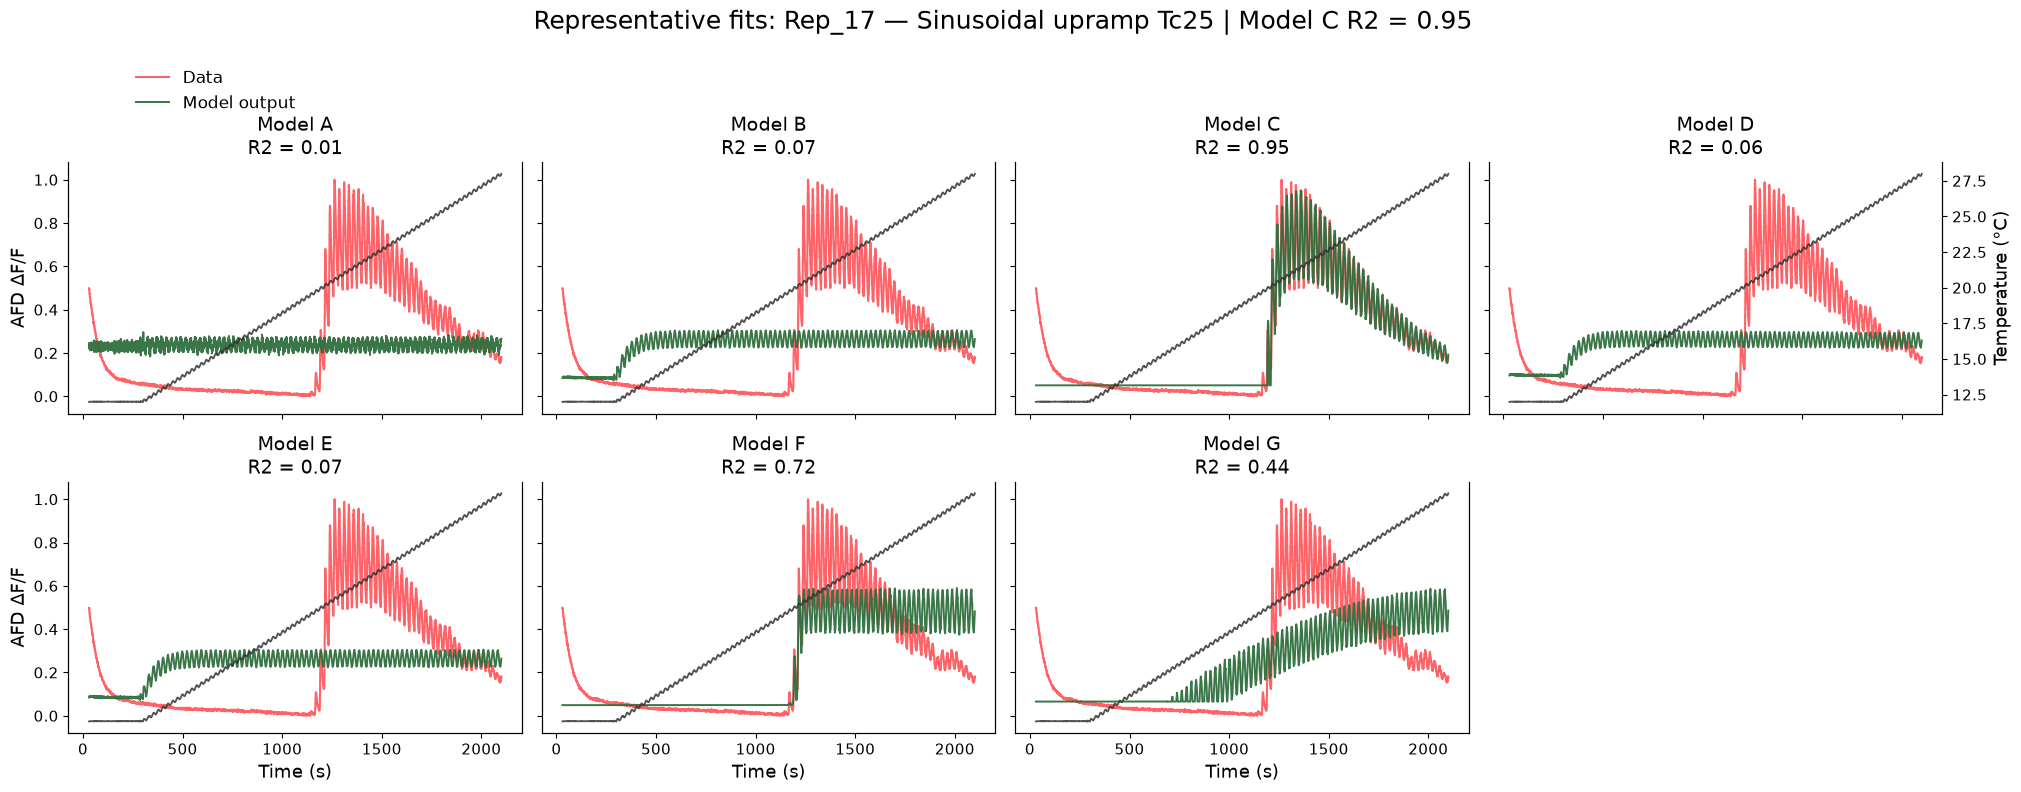


Representative fit summary:


,model,description,R2,a,b,tauD,T_on,k_shape,k_scale,tauA,norm_k,T_thr,sigmoid_slope,tau_ACT,K_ACT
0,Model A,Derivative only,0.005724,0.900686,0.229589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Model B,Leaky derivative,0.065293,20.279110,0.084265,59.999498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Model C,Leaky derivative + Gamma gain,0.950243,78.006737,0.050638,43.756755,20.002174,1.505894,2.666418,NaN,NaN,NaN,NaN,NaN,NaN
3,Model D,FCD-like dlog(T_K)/dt,0.055249,5474.696005,0.096147,59.999544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Model E,Feedback-like divisive normalization,0.065292,20.280588,0.084265,59.999968,NaN,NaN,NaN,3.154497,0.010135,NaN,NaN,NaN,NaN
5,Model F,Threshold/sigmoid control,0.715941,48.739461,0.049134,55.617200,NaN,NaN,NaN,NaN,NaN,20.080373,17.479947,NaN,NaN
6,Model G,ACT-style adaptive threshold,0.443644,0.855957,0.065578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.558299,137.671383


In [37]:
# ============================================================
# REVIEWER 3: representative fitted traces for Models A-G
# 2 x 4 plot showing Data, model output, and temperature
#
# This cell uses the per-worm Model A-G fits from the
# non-cross-validated reviewer comparison above.
# It does not refit anything; it rebuilds each model using the
# best-fit parameters already stored in alt_fit_df.
# ============================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER CONTROLS ----------------
REPRESENTATIVE_FIT_SELECTION = "best_model_c"  # "best_model_c", "median_model_c", or "manual"
REPRESENTATIVE_REP_IDX = None                  # used only if REPRESENTATIVE_FIT_SELECTION = "manual"; 0-based index
PLOT_TEMPERATURE_ON_RIGHT_AXIS = True
# Uses global SAVE_FIGURES and FIGURE_OUTPUT_DIR if defined above.
# ------------------------------------------------

required_repfit_names = [
    "Time_alt", "Temp_alt", "Ca_alt", "mask_alt", "rep_cols",
    "alt_fit_df", "alt_model_configs", "_score_alt_model_on_one_worm",
]
missing_repfit = [name for name in required_repfit_names if name not in globals()]
if missing_repfit:
    raise RuntimeError(
        "Run the Reviewer 3 non-cross-validated Model A-G comparison cell first. "
        f"Missing: {missing_repfit}"
    )

if "SAVE_FIGURES" not in globals():
    SAVE_FIGURES = False
if "FIGURE_OUTPUT_DIR" not in globals():
    FIGURE_OUTPUT_DIR = "."
if "dataset" not in globals():
    dataset = "Tc25 dataset"

# Choose a representative worm/replicate.
model_c_df = alt_fit_df[
    (alt_fit_df["model_id"] == "full_gamma") & np.isfinite(alt_fit_df["R2"])
].copy()
if model_c_df.empty:
    raise RuntimeError("Could not find finite Model C fits in alt_fit_df.")

if REPRESENTATIVE_FIT_SELECTION == "manual":
    if REPRESENTATIVE_REP_IDX is None:
        raise ValueError("Set REPRESENTATIVE_REP_IDX when REPRESENTATIVE_FIT_SELECTION = 'manual'.")
    rep_idx = int(REPRESENTATIVE_REP_IDX)
elif REPRESENTATIVE_FIT_SELECTION == "median_model_c":
    model_c_sorted = model_c_df.sort_values("R2").reset_index(drop=True)
    rep_idx = int(model_c_sorted.iloc[len(model_c_sorted) // 2]["rep_idx"])
elif REPRESENTATIVE_FIT_SELECTION == "best_model_c":
    rep_idx = int(model_c_df.sort_values("R2", ascending=False).iloc[0]["rep_idx"])
else:
    raise ValueError("REPRESENTATIVE_FIT_SELECTION must be 'best_model_c', 'median_model_c', or 'manual'.")

if rep_idx < 0 or rep_idx >= Ca_alt.shape[1]:
    raise IndexError(f"rep_idx={rep_idx} is outside the valid range 0 to {Ca_alt.shape[1]-1}.")

rep_name = str(rep_cols[rep_idx])
Calcium_rep = np.asarray(Ca_alt[:, rep_idx], dtype=float)

# Parameter names that may be present for different models.
possible_param_cols = [
    "tauD", "T_on", "k_shape", "k_scale",
    "tauA", "norm_k", "T_thr", "sigmoid_slope",
    "tau_ACT", "K_ACT",
]

fit_rows_for_plot = []
for cfg in alt_model_configs:
    model_id = cfg["id"]
    model_name = cfg["name"]
    model_desc = cfg["description"]

    row_df = alt_fit_df[
        (alt_fit_df["rep_idx"] == rep_idx) &
        (alt_fit_df["model_id"] == model_id)
    ].copy()
    if row_df.empty:
        raise RuntimeError(f"No fit found for rep_idx={rep_idx}, model_id={model_id}.")

    row = row_df.iloc[0]
    params = {}
    for col in possible_param_cols:
        if col in row.index and np.isfinite(row[col]):
            params[col] = float(row[col])

    R2, a, b, fit = _score_alt_model_on_one_worm(model_id, params, Calcium_rep)
    fit_rows_for_plot.append({
        "model_id": model_id,
        "model_name": model_name,
        "description": model_desc,
        "R2": R2,
        "a": a,
        "b": b,
        "fit": fit,
        "params": params,
    })

model_c_r2 = [r["R2"] for r in fit_rows_for_plot if r["model_id"] == "full_gamma"][0]

# Plot in a 2 x 4 layout.
fig, axes = plt.subplots(2, 4, figsize=(21.0, 8.2), sharex=True, sharey=True)
axes = axes.flatten()

# Plot styling.
data_color = "#ff5a5f"
fit_color = "#2f6f3e"
temp_color = "#333333"

# Use finite values for axes.
finite_y = Calcium_rep[np.isfinite(Calcium_rep)]
y_min = float(np.nanmin(finite_y)) if finite_y.size else 0.0
y_max = float(np.nanmax(finite_y)) if finite_y.size else 1.0
y_pad = 0.08 * max(1e-6, y_max - y_min)

finite_temp = Temp_alt[np.isfinite(Temp_alt)]
t_min = float(np.nanmin(finite_temp)) if finite_temp.size else 0.0
t_max = float(np.nanmax(finite_temp)) if finite_temp.size else 1.0
t_pad = 0.05 * max(1e-6, t_max - t_min)

for i, info in enumerate(fit_rows_for_plot):
    ax = axes[i]
    fit = np.asarray(info["fit"], dtype=float)

    ax.plot(Time_alt, Calcium_rep, color=data_color, lw=1.5, alpha=0.95, label="Data")
    ax.plot(Time_alt, fit, color=fit_color, lw=1.4, alpha=0.95, label="Model output")

    ax.set_title(
        f"{info['model_name']}\nR2 = {info['R2']:.2f}",
        fontsize=14,
        pad=6,
    )
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.tick_params(axis="both", labelsize=11)
    ax.spines["top"].set_visible(False)

    if i % 4 == 0:
        ax.set_ylabel("AFD ΔF/F", fontsize=13)
    if i >= 4:
        ax.set_xlabel("Time (s)", fontsize=13)

    if PLOT_TEMPERATURE_ON_RIGHT_AXIS:
        ax2 = ax.twinx()
        ax2.plot(Time_alt, Temp_alt, color=temp_color, lw=1.3, alpha=0.85, label="Temperature")
        ax2.set_ylim(t_min - t_pad, t_max + t_pad)
        ax2.spines["top"].set_visible(False)
        if i % 4 == 3:
            ax2.set_ylabel("Temperature (°C)", fontsize=13)
            ax2.tick_params(axis="y", labelsize=11)
        else:
            ax2.set_yticklabels([])
            ax2.tick_params(axis="y", length=0)

# Hide any unused panel(s). With seven models in a 2 x 4 layout,
# the eighth panel is intentionally left blank.
for j in range(len(fit_rows_for_plot), len(axes)):
    axes[j].set_visible(False)

# One shared legend for data/model output.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.08, 0.925), frameon=False, fontsize=12)

fig.suptitle(
    f"Representative fits: {rep_name} — {dataset} | Model C R2 = {model_c_r2:.2f}",
    fontsize=18,
    y=0.98,
)

fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.92])

if SAVE_FIGURES:
    os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)
    safe_dataset = re.sub(r"[^A-Za-z0-9_-]+", "_", str(dataset)).strip("_")
    safe_rep = re.sub(r"[^A-Za-z0-9_-]+", "_", str(rep_name)).strip("_")
    svg_filename = f"{safe_dataset}_representative_fit_models_A_G_{safe_rep}.svg"
    svg_path = os.path.join(FIGURE_OUTPUT_DIR, svg_filename)
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    print(f"Saved representative fit SVG as: {svg_path}")

plt.show()

# Helpful table for checking which parameters were used in the representative plot.
rep_fit_summary_df = pd.DataFrame([
    {
        "model": r["model_name"],
        "description": r["description"],
        "R2": r["R2"],
        "a": r["a"],
        "b": r["b"],
        **r["params"],
    }
    for r in fit_rows_for_plot
])
print("\nRepresentative fit summary:")
display(rep_fit_summary_df)


Saved Models B-G figure as: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/Sinusoidal_upramp_Tc25_representative_models_B_to_G_Rep_17_2x3.svg


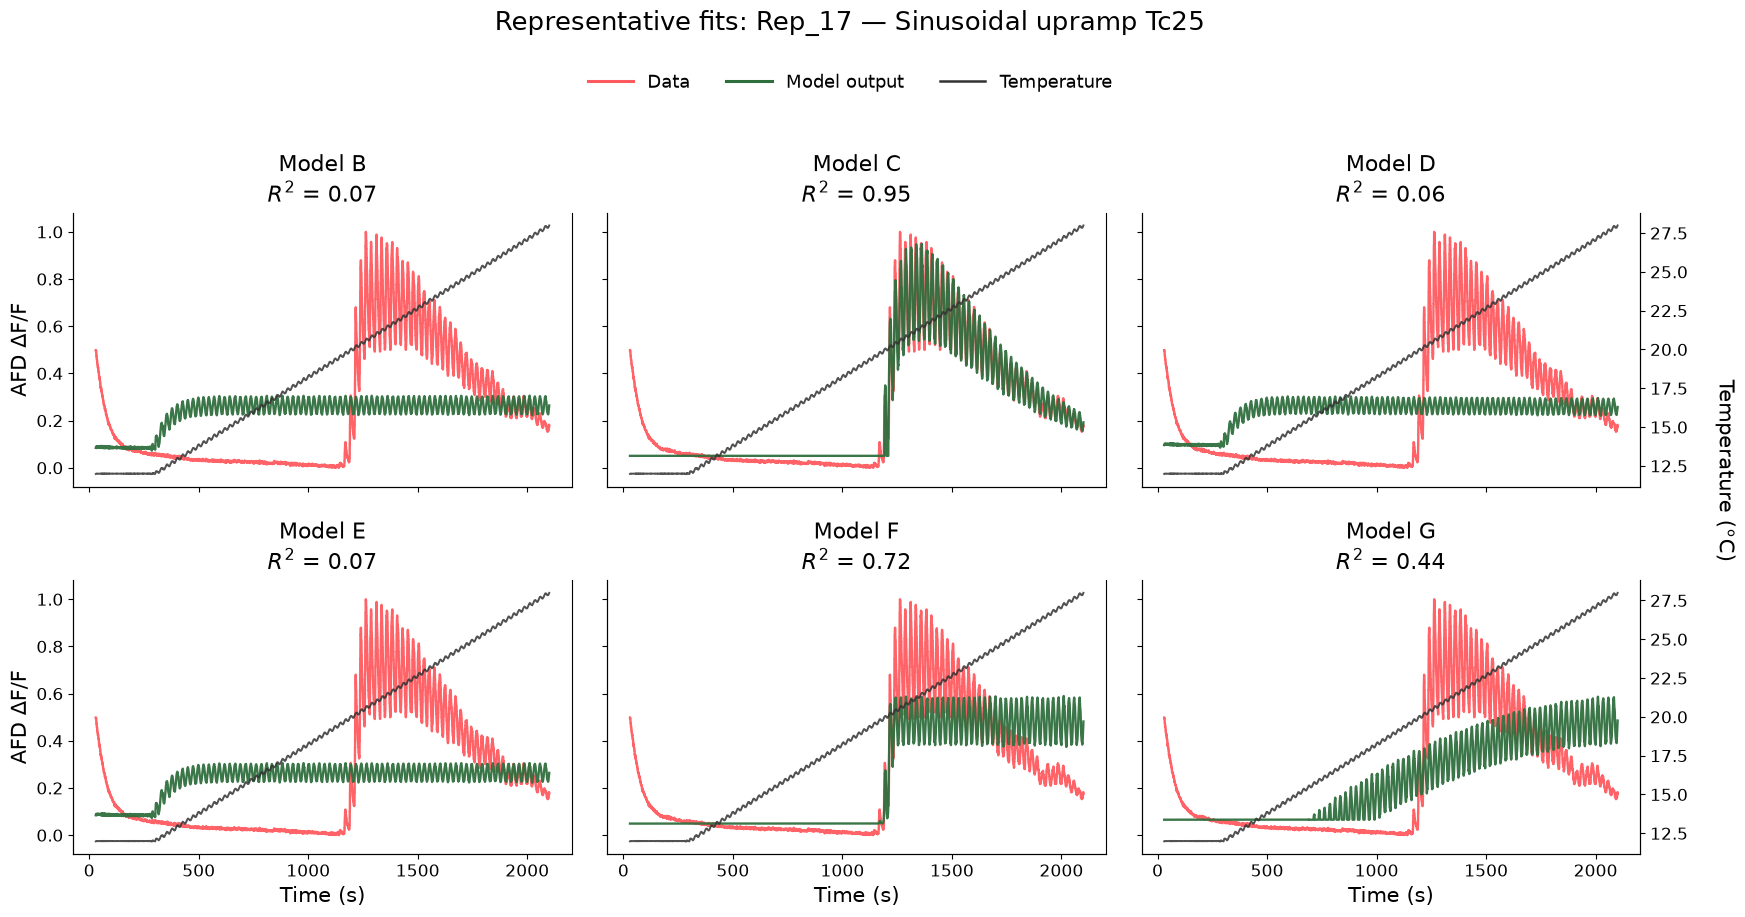

In [38]:
# ============================================================
# REPRESENTATIVE FITS FOR MODELS B-G
# 2 rows x 3 columns
#
# This cell does not refit any model.
# It uses the representative replicate and fitted traces already
# generated by the preceding Models A-G representative-fit cell.
# ============================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Models shown from left to right and top to bottom:
#
# Top row:    Model B, Model C, Model D
# Bottom row: Model E, Model F, Model G

MODEL_ORDER_B_TO_G = [
    "deriv_tau",       # Model B
    "full_gamma",      # Model C
    "fcd_like",        # Model D
    "feedback_norm",   # Model E
    "threshold_sig",   # Model F
    "act_threshold",   # Model G
]

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_names = [
    "Time_alt",
    "Temp_alt",
    "Calcium_rep",
    "fit_rows_for_plot",
    "rep_name",
    "dataset",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "Run the preceding representative-fit cell first. "
        f"Missing variables: {missing_names}"
    )

if "SAVE_FIGURES" not in globals():
    SAVE_FIGURES = False

if "FIGURE_OUTPUT_DIR" not in globals():
    FIGURE_OUTPUT_DIR = "."

# ------------------------------------------------------------
# Retrieve the stored fitted trace for each model
# ------------------------------------------------------------

fit_lookup = {
    row["model_id"]: row
    for row in fit_rows_for_plot
}

missing_models = [
    model_id
    for model_id in MODEL_ORDER_B_TO_G
    if model_id not in fit_lookup
]

if missing_models:
    raise RuntimeError(
        "The following fitted models were not found: "
        f"{missing_models}"
    )

selected_fits = [
    fit_lookup[model_id]
    for model_id in MODEL_ORDER_B_TO_G
]

# ------------------------------------------------------------
# Preserve colors from the existing representative-fit figure
# ------------------------------------------------------------

DATA_COLOR = globals().get(
    "data_color",
    "#ff5a5f",
)

FIT_COLOR = globals().get(
    "fit_color",
    "#2f6f3e",
)

TEMP_COLOR = globals().get(
    "temp_color",
    "#333333",
)

# ------------------------------------------------------------
# Determine common calcium-axis limits
# ------------------------------------------------------------

finite_calcium = np.asarray(
    Calcium_rep,
    dtype=float,
)

finite_calcium = finite_calcium[
    np.isfinite(finite_calcium)
]

if finite_calcium.size:
    calcium_min = float(
        np.nanmin(finite_calcium)
    )
    calcium_max = float(
        np.nanmax(finite_calcium)
    )
else:
    calcium_min = 0.0
    calcium_max = 1.0

calcium_range = max(
    calcium_max - calcium_min,
    1e-6,
)

calcium_padding = 0.08 * calcium_range

# ------------------------------------------------------------
# Determine common temperature-axis limits
# ------------------------------------------------------------

finite_temperature = np.asarray(
    Temp_alt,
    dtype=float,
)

finite_temperature = finite_temperature[
    np.isfinite(finite_temperature)
]

if finite_temperature.size:
    temperature_min = float(
        np.nanmin(finite_temperature)
    )
    temperature_max = float(
        np.nanmax(finite_temperature)
    )
else:
    temperature_min = 0.0
    temperature_max = 1.0

temperature_range = max(
    temperature_max - temperature_min,
    1e-6,
)

temperature_padding = 0.05 * temperature_range

# ------------------------------------------------------------
# Plot Models B-G in a 2 x 3 arrangement
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18.0, 9.5),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes)

# Keep references to the temperature axes
temperature_axes = []

for plot_index, model_info in enumerate(selected_fits):

    # Correct indexing for a 2-row x 3-column grid
    row_index = plot_index // 3
    column_index = plot_index % 3

    ax = axes[row_index, column_index]

    model_fit = np.asarray(
        model_info["fit"],
        dtype=float,
    )

    # --------------------------------------------------------
    # Calcium data
    # --------------------------------------------------------

    ax.plot(
        Time_alt,
        Calcium_rep,
        color=DATA_COLOR,
        linewidth=1.7,
        alpha=0.95,
        label="Data",
        zorder=3,
    )

    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    ax.plot(
        Time_alt,
        model_fit,
        color=FIT_COLOR,
        linewidth=1.7,
        alpha=0.95,
        label="Model output",
        zorder=4,
    )

    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        f"{model_info['model_name']}\n"
        f"$R^2$ = {model_info['R2']:.2f}",
        fontsize=16,
        pad=8,
    )

    ax.set_ylim(
        calcium_min - calcium_padding,
        calcium_max + calcium_padding,
    )

    ax.tick_params(
        axis="both",
        labelsize=12,
    )

    ax.spines["top"].set_visible(False)

    # Calcium-axis labels only on the left column
    if column_index == 0:
        ax.set_ylabel(
            "AFD ΔF/F",
            fontsize=15,
        )

    # Time-axis labels only on the bottom row
    if row_index == 1:
        ax.set_xlabel(
            "Time (s)",
            fontsize=15,
        )

    # --------------------------------------------------------
    # Temperature on the right axis
    # --------------------------------------------------------

    ax_temperature = ax.twinx()
    temperature_axes.append(ax_temperature)

    ax_temperature.plot(
        Time_alt,
        Temp_alt,
        color=TEMP_COLOR,
        linewidth=1.4,
        alpha=0.85,
        zorder=2,
    )

    ax_temperature.set_ylim(
        temperature_min - temperature_padding,
        temperature_max + temperature_padding,
    )

    ax_temperature.spines["top"].set_visible(False)

    # Show temperature ticks only in the rightmost column
    if column_index == 2:
        ax_temperature.tick_params(
            axis="y",
            labelsize=12,
            right=True,
            labelright=True,
        )
    else:
        ax_temperature.tick_params(
            axis="y",
            right=False,
            labelright=False,
            length=0,
        )

        ax_temperature.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Shared temperature-axis label on the right side
# ------------------------------------------------------------

fig.text(
    0.992,
    0.50,
    "Temperature (°C)",
    va="center",
    ha="right",
    rotation=270,
    fontsize=15,
)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        color=DATA_COLOR,
        linewidth=2.2,
        label="Data",
    ),
    Line2D(
        [0],
        [0],
        color=FIT_COLOR,
        linewidth=2.2,
        label="Model output",
    ),
    Line2D(
        [0],
        [0],
        color=TEMP_COLOR,
        linewidth=1.8,
        label="Temperature",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=3,
    frameon=False,
    fontsize=13,
    handlelength=2.5,
    columnspacing=2.0,
)

# ------------------------------------------------------------
# Figure title
# ------------------------------------------------------------

fig.suptitle(
    f"Representative fits: {rep_name} — {dataset}",
    fontsize=19,
    y=0.985,
)

fig.tight_layout(
    rect=[
        0.025,  # left
        0.025,  # bottom
        0.965,  # right
        0.895,  # top
    ],
    h_pad=2.0,
    w_pad=2.2,
)

# ------------------------------------------------------------
# Save only when SAVE_FIGURES is True
# ------------------------------------------------------------

if SAVE_FIGURES:

    os.makedirs(
        FIGURE_OUTPUT_DIR,
        exist_ok=True,
    )

    safe_dataset = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(dataset),
    ).strip("_")

    safe_rep_name = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(rep_name),
    ).strip("_")

    output_filename = (
        f"{safe_dataset}_representative_models_B_to_G_"
        f"{safe_rep_name}_2x3.svg"
    )

    output_path = os.path.join(
        FIGURE_OUTPUT_DIR,
        output_filename,
    )

    fig.savefig(
        output_path,
        format="svg",
        bbox_inches="tight",
    )

    print(
        f"Saved Models B-G figure as: {output_path}"
    )

plt.show()

Saved overlay panel as: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/Panel_F_Sinusoidal_upramp_Tc25_models_B_to_G_overlay_Rep_17.svg


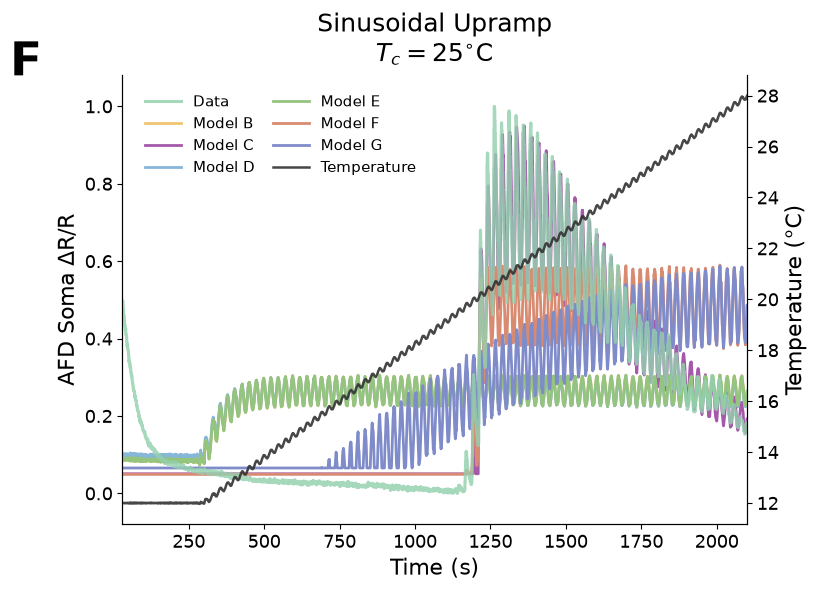

In [39]:
# ============================================================
# OVERLAY OF ALL RETAINED MODELS: MODELS B-G
#
# Sinusoidal upramp notebook -> Panel F
# Realistic stimulus notebook -> Panel G
#
# This cell does not refit any model.
# It uses the fitted traces generated by the preceding
# representative Models A-G cell.
# ============================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# The six models retained for the figure
OVERLAY_MODEL_ORDER = [
    "deriv_tau",       # Model B
    "full_gamma",      # Model C
    "fcd_like",        # Model D
    "feedback_norm",   # Model E
    "threshold_sig",   # Model F
    "act_threshold",   # Model G
]

# Colors match the corresponding bars in the Models A-G plot
MODEL_COLORS = {
    "deriv_tau":     "#f0c571",  # Model B: gold
    "full_gamma":    "#a559aa",  # Model C: purple
    "fcd_like":      "#86b6d8",  # Model D: blue
    "feedback_norm": "#95c47f",  # Model E: green
    "threshold_sig": "#d98b72",  # Model F: salmon
    "act_threshold": "#7f8cc9",  # Model G: periwinkle
}

# Preserve the data and temperature colors from the existing F/G panels
OVERLAY_DATA_COLOR = "#93d0ae"
OVERLAY_TEMPERATURE_COLOR = "#333333"

# Change this label here if ΔF/F is preferred
OVERLAY_Y_LABEL = "AFD Soma ΔR/R"

# Safety checks
required_names = [
    "Time_alt",
    "Temp_alt",
    "Calcium_rep",
    "fit_rows_for_plot",
    "dataset",
    "rep_name",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Run the preceding representative-fit cell first. "
        f"Missing variables: {missing_names}"
    )

if "SAVE_FIGURES" not in globals():
    SAVE_FIGURES = False

if "FIGURE_OUTPUT_DIR" not in globals():
    FIGURE_OUTPUT_DIR = "."

# Retrieve the stored model fits
fit_lookup = {
    row["model_id"]: row
    for row in fit_rows_for_plot
}

missing_models = [
    model_id for model_id in OVERLAY_MODEL_ORDER
    if model_id not in fit_lookup
]

if missing_models:
    raise RuntimeError(
        "The following fitted models were not found: "
        f"{missing_models}"
    )

overlay_fits = [
    fit_lookup[model_id]
    for model_id in OVERLAY_MODEL_ORDER
]

# Automatically determine whether this is panel F or panel G
dataset_lower = str(dataset).lower()

if "sinusoidal" in dataset_lower or "upramp" in dataset_lower:
    panel_letter = "F"
    stimulus_title = "Sinusoidal Upramp"
elif "realistic" in dataset_lower:
    panel_letter = "G"
    stimulus_title = "Realistic Stimulus"
else:
    panel_letter = ""
    stimulus_title = str(dataset)

# Axis limits
finite_calcium = np.asarray(Calcium_rep, dtype=float)
finite_calcium = finite_calcium[np.isfinite(finite_calcium)]

if finite_calcium.size:
    calcium_min = float(np.nanmin(finite_calcium))
    calcium_max = float(np.nanmax(finite_calcium))
else:
    calcium_min = 0.0
    calcium_max = 1.0

calcium_range = max(calcium_max - calcium_min, 1e-6)
calcium_padding = 0.08 * calcium_range

finite_temperature = np.asarray(Temp_alt, dtype=float)
finite_temperature = finite_temperature[np.isfinite(finite_temperature)]

if finite_temperature.size:
    temperature_min = float(np.nanmin(finite_temperature))
    temperature_max = float(np.nanmax(finite_temperature))
else:
    temperature_min = 0.0
    temperature_max = 1.0

temperature_range = max(
    temperature_max - temperature_min,
    1e-6,
)

temperature_padding = 0.05 * temperature_range

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.3, 6.0),
)

# Plot the six model predictions
for model_info in overlay_fits:

    model_id = model_info["model_id"]
    model_fit = np.asarray(
        model_info["fit"],
        dtype=float,
    )

    ax.plot(
        Time_alt,
        model_fit,
        color=MODEL_COLORS[model_id],
        linewidth=2.0,
        alpha=1.0,
        label=model_info["model_name"],
        zorder=3,
    )

# Plot the calcium data after the models so that it remains visible
ax.plot(
    Time_alt,
    Calcium_rep,
    color=OVERLAY_DATA_COLOR,
    linewidth=2.2,
    alpha=0.82,
    label="Data",
    zorder=5,
)

ax.set_xlim(
    float(np.nanmin(Time_alt)),
    float(np.nanmax(Time_alt)),
)

ax.set_ylim(
    calcium_min - calcium_padding,
    calcium_max + calcium_padding,
)

ax.set_xlabel(
    "Time (s)",
    fontsize=16,
)

ax.set_ylabel(
    OVERLAY_Y_LABEL,
    fontsize=16,
)

ax.tick_params(
    axis="both",
    labelsize=13,
)

ax.spines["top"].set_visible(False)

# Temperature on the right axis
ax_temperature = ax.twinx()

temperature_line, = ax_temperature.plot(
    Time_alt,
    Temp_alt,
    color=OVERLAY_TEMPERATURE_COLOR,
    linewidth=1.8,
    alpha=0.90,
    label="Temperature",
    zorder=2,
)

ax_temperature.set_ylim(
    temperature_min - temperature_padding,
    temperature_max + temperature_padding,
)

ax_temperature.set_ylabel(
    "Temperature (°C)",
    fontsize=16,
)

ax_temperature.tick_params(
    axis="y",
    labelsize=13,
)

ax_temperature.spines["top"].set_visible(False)

# Panel title
ax.set_title(
    f"{stimulus_title}\n"
    r"$T_c = 25^{\circ}\mathrm{C}$",
    fontsize=18,
    pad=10,
)

# Large panel letter
if panel_letter:
    ax.text(
        -0.18,
        1.08,
        panel_letter,
        transform=ax.transAxes,
        fontsize=34,
        fontweight="bold",
        va="top",
        ha="left",
    )

# Combine calcium/model and temperature legends
left_handles, left_labels = ax.get_legend_handles_labels()
right_handles, right_labels = ax_temperature.get_legend_handles_labels()

# Place Data first, followed by Models B-G and Temperature
handle_by_label = dict(
    zip(
        left_labels + right_labels,
        left_handles + right_handles,
    )
)

desired_legend_order = (
    ["Data"]
    + [fit_lookup[model_id]["model_name"]
       for model_id in OVERLAY_MODEL_ORDER]
    + ["Temperature"]
)

legend_handles = [
    handle_by_label[label]
    for label in desired_legend_order
    if label in handle_by_label
]

legend_labels = [
    label
    for label in desired_legend_order
    if label in handle_by_label
]

ax.legend(
    legend_handles,
    legend_labels,
    loc="upper left",
    bbox_to_anchor=(0.015, 0.985),
    frameon=False,
    fontsize=10.5,
    ncol=2,
    columnspacing=1.2,
    handlelength=2.5,
)

fig.tight_layout()

# Save only when SAVE_FIGURES is True
if SAVE_FIGURES:

    os.makedirs(
        FIGURE_OUTPUT_DIR,
        exist_ok=True,
    )

    safe_dataset = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(dataset),
    ).strip("_")

    safe_rep_name = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(rep_name),
    ).strip("_")

    output_filename = (
        f"Panel_{panel_letter}_{safe_dataset}_"
        f"models_B_to_G_overlay_{safe_rep_name}.svg"
    )

    output_path = os.path.join(
        FIGURE_OUTPUT_DIR,
        output_filename,
    )

    fig.savefig(
        output_path,
        format="svg",
        bbox_inches="tight",
    )

    print(f"Saved overlay panel as: {output_path}")

plt.show()

Saved Models A-G overlay panel as: /Users/sk3526/Documents/Yale/modelling/figures_with_fits/figures_07_28_2026/sinusoidal_upramp/Panel_F_Sinusoidal_upramp_Tc25_models_A_to_G_overlay_Rep_17.svg


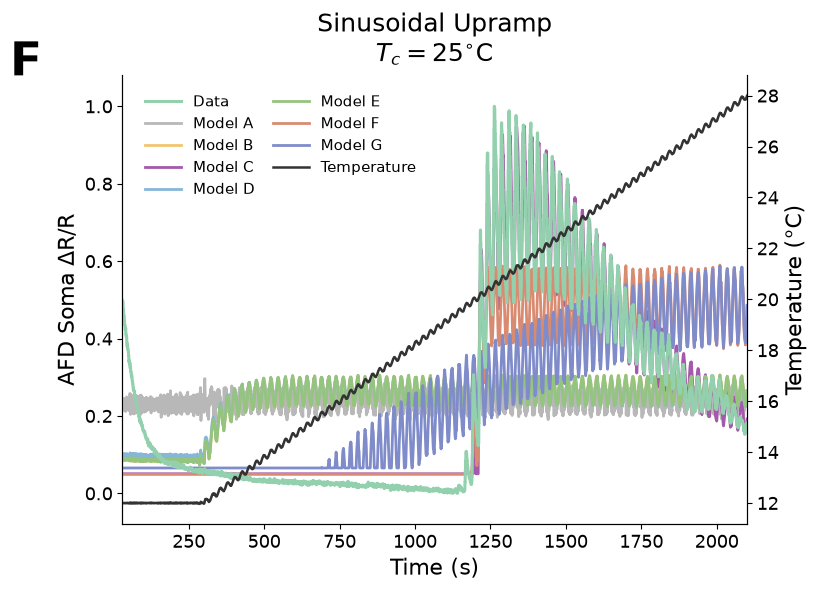

In [40]:
# ============================================================
# OVERLAY OF ALL MODELS: MODELS A-G
#
# Sinusoidal upramp notebook -> Panel F
# Realistic stimulus notebook -> Panel G
#
# This cell does not refit any model.
# It uses the fitted traces generated by the preceding
# representative Models A-G cell.
# ============================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Models shown in the overlay
# ------------------------------------------------------------

OVERLAY_MODEL_ORDER = [
    "deriv_gain",      # Model A
    "deriv_tau",       # Model B
    "full_gamma",      # Model C
    "fcd_like",        # Model D
    "feedback_norm",   # Model E
    "threshold_sig",   # Model F
    "act_threshold",   # Model G
]

# Colors match the Models A-G comparison bar plot
MODEL_COLORS = {
    "deriv_gain":    "#b8b8b8",  # Model A: gray
    "deriv_tau":     "#f0c571",  # Model B: gold
    "full_gamma":    "#a559aa",  # Model C: purple
    "fcd_like":      "#86b6d8",  # Model D: blue
    "feedback_norm": "#95c47f",  # Model E: green
    "threshold_sig": "#d98b72",  # Model F: salmon
    "act_threshold": "#7f8cc9",  # Model G: periwinkle
}

# Data and temperature colors
OVERLAY_DATA_COLOR = "#93d0ae"
OVERLAY_TEMPERATURE_COLOR = "#333333"

OVERLAY_Y_LABEL = "AFD Soma ΔR/R"

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_names = [
    "Time_alt",
    "Temp_alt",
    "Calcium_rep",
    "fit_rows_for_plot",
    "dataset",
    "rep_name",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "Run the preceding representative-fit cell first. "
        f"Missing variables: {missing_names}"
    )

if "SAVE_FIGURES" not in globals():
    SAVE_FIGURES = False

if "FIGURE_OUTPUT_DIR" not in globals():
    FIGURE_OUTPUT_DIR = "."

# ------------------------------------------------------------
# Retrieve stored model fits
# ------------------------------------------------------------

fit_lookup = {
    row["model_id"]: row
    for row in fit_rows_for_plot
}

missing_models = [
    model_id
    for model_id in OVERLAY_MODEL_ORDER
    if model_id not in fit_lookup
]

if missing_models:
    raise RuntimeError(
        "The following fitted models were not found: "
        f"{missing_models}"
    )

overlay_fits = [
    fit_lookup[model_id]
    for model_id in OVERLAY_MODEL_ORDER
]

# ------------------------------------------------------------
# Determine whether this is panel F or panel G
# ------------------------------------------------------------

dataset_lower = str(dataset).lower()

if "sinusoidal" in dataset_lower or "upramp" in dataset_lower:
    panel_letter = "F"
    stimulus_title = "Sinusoidal Upramp"

elif "realistic" in dataset_lower:
    panel_letter = "G"
    stimulus_title = "Realistic Stimulus"

else:
    panel_letter = ""
    stimulus_title = str(dataset)

# ------------------------------------------------------------
# Calcium-axis limits
# ------------------------------------------------------------

finite_calcium = np.asarray(
    Calcium_rep,
    dtype=float,
)

finite_calcium = finite_calcium[
    np.isfinite(finite_calcium)
]

if finite_calcium.size:
    calcium_min = float(np.nanmin(finite_calcium))
    calcium_max = float(np.nanmax(finite_calcium))
else:
    calcium_min = 0.0
    calcium_max = 1.0

calcium_range = max(
    calcium_max - calcium_min,
    1e-6,
)

calcium_padding = 0.08 * calcium_range

# ------------------------------------------------------------
# Temperature-axis limits
# ------------------------------------------------------------

finite_temperature = np.asarray(
    Temp_alt,
    dtype=float,
)

finite_temperature = finite_temperature[
    np.isfinite(finite_temperature)
]

if finite_temperature.size:
    temperature_min = float(np.nanmin(finite_temperature))
    temperature_max = float(np.nanmax(finite_temperature))
else:
    temperature_min = 0.0
    temperature_max = 1.0

temperature_range = max(
    temperature_max - temperature_min,
    1e-6,
)

temperature_padding = 0.05 * temperature_range

# ------------------------------------------------------------
# Create overlay plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.3, 6.0),
)

# Plot all seven model predictions
for model_info in overlay_fits:

    model_id = model_info["model_id"]

    model_fit = np.asarray(
        model_info["fit"],
        dtype=float,
    )

    ax.plot(
        Time_alt,
        model_fit,
        color=MODEL_COLORS[model_id],
        linewidth=2.0,
        alpha=1.0,
        label=model_info["model_name"],
        zorder=3,
    )

# Plot calcium data above the model traces
ax.plot(
    Time_alt,
    Calcium_rep,
    color=OVERLAY_DATA_COLOR,
    linewidth=2.2,
    alpha=1.0,
    label="Data",
    zorder=5,
)

ax.set_xlim(
    float(np.nanmin(Time_alt)),
    float(np.nanmax(Time_alt)),
)

ax.set_ylim(
    calcium_min - calcium_padding,
    calcium_max + calcium_padding,
)

ax.set_xlabel(
    "Time (s)",
    fontsize=16,
)

ax.set_ylabel(
    OVERLAY_Y_LABEL,
    fontsize=16,
)

ax.tick_params(
    axis="both",
    labelsize=13,
)

ax.spines["top"].set_visible(False)

# ------------------------------------------------------------
# Temperature on the right axis
# ------------------------------------------------------------

ax_temperature = ax.twinx()

ax_temperature.plot(
    Time_alt,
    Temp_alt,
    color=OVERLAY_TEMPERATURE_COLOR,
    linewidth=1.8,
    alpha=1.0,
    label="Temperature",
    zorder=2,
)

ax_temperature.set_ylim(
    temperature_min - temperature_padding,
    temperature_max + temperature_padding,
)

ax_temperature.set_ylabel(
    "Temperature (°C)",
    fontsize=16,
)

ax_temperature.tick_params(
    axis="y",
    labelsize=13,
)

ax_temperature.spines["top"].set_visible(False)

# ------------------------------------------------------------
# Panel title
# ------------------------------------------------------------

ax.set_title(
    f"{stimulus_title}\n"
    r"$T_c = 25^{\circ}\mathrm{C}$",
    fontsize=18,
    pad=10,
)

# Large panel letter
if panel_letter:
    ax.text(
        -0.18,
        1.08,
        panel_letter,
        transform=ax.transAxes,
        fontsize=34,
        fontweight="bold",
        va="top",
        ha="left",
    )

# ------------------------------------------------------------
# Combined legend
# ------------------------------------------------------------

left_handles, left_labels = ax.get_legend_handles_labels()

right_handles, right_labels = (
    ax_temperature.get_legend_handles_labels()
)

handle_by_label = dict(
    zip(
        left_labels + right_labels,
        left_handles + right_handles,
    )
)

desired_legend_order = (
    ["Data"]
    + [
        fit_lookup[model_id]["model_name"]
        for model_id in OVERLAY_MODEL_ORDER
    ]
    + ["Temperature"]
)

legend_handles = [
    handle_by_label[label]
    for label in desired_legend_order
    if label in handle_by_label
]

legend_labels = [
    label
    for label in desired_legend_order
    if label in handle_by_label
]

ax.legend(
    legend_handles,
    legend_labels,
    loc="upper left",
    bbox_to_anchor=(0.015, 0.985),
    frameon=False,
    fontsize=10.5,
    ncol=2,
    columnspacing=1.2,
    handlelength=2.5,
)

fig.tight_layout()

# ------------------------------------------------------------
# Save only when SAVE_FIGURES is True
# ------------------------------------------------------------

if SAVE_FIGURES:

    os.makedirs(
        FIGURE_OUTPUT_DIR,
        exist_ok=True,
    )

    safe_dataset = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(dataset),
    ).strip("_")

    safe_rep_name = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(rep_name),
    ).strip("_")

    output_filename = (
        f"Panel_{panel_letter}_{safe_dataset}_"
        f"models_A_to_G_overlay_{safe_rep_name}.svg"
    )

    output_path = os.path.join(
        FIGURE_OUTPUT_DIR,
        output_filename,
    )

    fig.savefig(
        output_path,
        format="svg",
        bbox_inches="tight",
    )

    print(
        f"Saved Models A-G overlay panel as: {output_path}"
    )

plt.show()